# NF-ToN-IoT-v3 

## Objective

This notebook performs an initial exploratory data analysis (EDA) of the
NF-ToN-IoT-v3 intrusion detection dataset.

The main objectives are:

- Understand the dataset structure and feature schema
- Analyze data types and missing values
- Explore attack label distributions and class imbalance
- Identify networking and temporal features relevant for graph construction
- Evaluate dataset scalability and memory footprint
- Prepare the foundation for graph-based intrusion detection experiments

This exploration will guide the design of:
- preprocessing pipelines,
- graph construction strategies,
- and future federated GNN experiments.
```

# NF-ToN-IoT-v3 — Dataset Reference Card

> **Source**: University of Queensland — ML-Based NIDS Datasets  
> **Published in**: Luay et al., *"Temporal Analysis of NetFlow Datasets for Network Intrusion Detection Systems"*, arXiv:2503.04404, 2025.

---

## Overview

| Property | Value |
|---|---|
| Full Name | NF-ToN-IoT-v3 (NetFlow-based Threat of Things IoT, version 3) |
| Base Dataset | ToN-IoT |
| Version | NetFlow V3 — 53 features (43 base + 10 temporal) |
| Format | CSV / Parquet |
| Total Flows | 27,520,260 |
| Benign Flows | 16,792,214 (61.02%) |
| Attack Flows | 10,728,046 (38.98%) |
| Columns | 55 (51 features + Label + Attack + 2 IP addresses kept as strings) |
| Feature Standard | NetFlow v9 enriched with nDPI deep packet inspection |
| Binary Task | Benign vs. Attack (2 classes) |
| Multi-class Task | 10 classes (1 benign + 9 attack types) |

NF-ToN-IoT-v3 is a NetFlow-based version of the well-known ToN-IoT dataset, enhanced
with additional NetFlow features and labelled according to its respective attack
categories. Each row represents one **network flow** — a bidirectional stream of packets
between a source and destination sharing the same 5-tuple (source IP, destination IP,
source port, destination port, protocol). It is the third and most feature-rich version
of the NF-ToN-IoT series, adding 10 temporal NetFlow features on top of the 43 features
present in v2.

---

## Class Distribution

| Class | Count | Percentage | Description |
|---|---|---|---|
| Benign | 16,792,214 | 61.02% | Normal unmalicious flows |
| DDoS | 4,141,256 | 15.05% | Distributed Denial of Service — multiple distributed sources flooding a target |
| XSS | 2,834,435 | 10.30% | Cross-Site Scripting — malicious scripts injected via web applications |
| Password | 1,594,777 | 5.80% | Brute-force or sniffing attacks aimed at retrieving passwords |
| Scanning | 1,358,977 | 4.94% | Port and host scanning techniques to discover network information |
| Injection | 381,777 | 1.39% | SQL or code injection attacks supplying untrusted inputs |
| DoS | 203,456 | 0.74% | Single-source Denial of Service overloading system resources |
| Backdoor | 203,384 | 0.74% | Remote-access attacks via specially constructed client applications |
| MITM | 6,013 | 0.02% | Man-in-the-Middle — attacker intercepts traffic between victim and host |
| Ransomware | 3,971 | 0.01% | Encrypts host files and demands compensation for decryption |
| **Total** | **27,520,260** | **100%** | |

**Imbalance observations:**
- DDoS is the dominant attack class, accounting for over 38% of all attack flows.
- MITM and Ransomware are severely under-represented, with fewer than 10,000 samples each.
- The binary split (61% benign / 39% attack) is moderate and manageable.
- The multi-class problem is significantly harder due to the 1,000x difference in sample
  count between the largest attack class (DDoS: 4.1M) and the smallest (Ransomware: 3,971).

---

## Feature Set

NF-ToN-IoT-v3 contains **53 NetFlow features** split into two groups:

| Group | Count | Description |
|---|---|---|
| Base NetFlow features (shared with v2) | 43 | Standard flow statistics exported by the NetFlow probe |
| Temporal features (new in v3) | 10 | Inter-arrival time statistics and flow timestamps |

The 10 temporal features added in v3 are:
`FLOW_START_MILLISECONDS`, `FLOW_END_MILLISECONDS`,
`SRC_TO_DST_IAT_MIN`, `SRC_TO_DST_IAT_MAX`, `SRC_TO_DST_IAT_AVG`, `SRC_TO_DST_IAT_STDDEV`,
`DST_TO_SRC_IAT_MIN`, `DST_TO_SRC_IAT_MAX`, `DST_TO_SRC_IAT_AVG`, `DST_TO_SRC_IAT_STDDEV`.

---

## Column Reference

### 1. Flow Timestamps

Unix timestamps in milliseconds since epoch (1 January 1970 UTC).
Part of the 10 temporal features introduced in v3.

| Column | Dtype | Unique Values | Description |
|---|---|---|---|
| `FLOW_START_MILLISECONDS` | Int64 | 12,299,784 | Timestamp of the first packet in the flow |
| `FLOW_END_MILLISECONDS` | Int64 | 12,439,429 | Timestamp of the last packet in the flow |

Very high cardinality — not directly usable as raw ML features. Their primary value is
for **temporal graph construction**: connecting flows occurring within a time window,
preserving flow ordering, and building time-windowed aggregations. Derived features
such as `hour_of_day` and `day_of_week` can be extracted for model input.
`FLOW_END_MILLISECONDS` is largely redundant given `FLOW_DURATION_MILLISECONDS`.

---

### 2. Network Identifiers

| Column | Dtype | Unique Values | Description |
|---|---|---|---|
| `IPV4_SRC_ADDR` | String | 15,270 | Source IPv4 address |
| `IPV4_DST_ADDR` | String | 8,777 | Destination IPv4 address |
| `L4_SRC_PORT` | Int64 | 65,536 | Source Layer 4 port number (0 – 65,535) |
| `L4_DST_PORT` | Int64 | 65,536 | Destination Layer 4 port number (0 – 65,535) |

**`IPV4_SRC_ADDR`** — Source IPv4 address. 15,270 unique addresses reflecting the bounded
IoT testbed topology. Not usable as a raw feature for ML. Serves as a node identifier
for graph-based approaches.

**`IPV4_DST_ADDR`** — Destination IPv4 address. Fewer unique destinations (8,777) than
sources is expected: attacks typically target a concentrated set of victim machines.

**`L4_SRC_PORT`** / **`L4_DST_PORT`** — Full 0–65,535 range observed. Raw integer
treatment implies a false numeric ordering. Recommended preprocessing: bin into three
semantic ranges:

| Range | Category | Description |
|---|---|---|
| 0 – 1,023 | Well-known | System services: HTTP=80, HTTPS=443, SSH=22, DNS=53, FTP=21 |
| 1,024 – 49,151 | Registered | Application-assigned ports |
| 49,152 – 65,535 | Dynamic / Ephemeral | OS-assigned for outgoing connections |

Destination ports are more informative than source ports for attack detection.

---

### 3. Protocol Fields

Categorical codes stored as integers. Numeric ordering is meaningless — must be treated
as categories.

| Column | Dtype | Unique Values | Description |
|---|---|---|---|
| `PROTOCOL` | Int64 | 5 | IANA Layer 4 transport protocol code |
| `L7_PROTO` | Int64 | 133 | nDPI application layer protocol code |

**`PROTOCOL`** — 5 unique values in this dataset:

| Code | Protocol | Notes |
|---|---|---|
| 0 | HOPOPT | IPv6 Hop-by-Hop Options |
| 1 | ICMP | Internet Control Message Protocol |
| 6 | TCP | Transmission Control Protocol (majority of flows) |
| 17 | UDP | User Datagram Protocol |
| 58 | ICMPv6 | ICMP for IPv6 |

**`L7_PROTO`** — Application protocol detected by nDPI. 133 unique codes. Selected values:

| Code | Protocol | Code | Protocol |
|---|---|---|---|
| 0 | Unknown | 21 | FTP |
| 5 | DNS | 62 | NetBIOS |
| 7 | HTTP | 65 | DHCP |
| 10 | SMTP | 81 | NTP |
| 18 | SSH | 91 | HTTPS |
| — | — | 161 | SNMP |

---

### 4. Flow Volume

True continuous features with heavy right-skewed distributions. Log-transform recommended.

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `IN_BYTES` | Int64 | 18,423 | 0.0% | Total bytes from source to destination |
| `IN_PKTS` | Int64 | 2,421 | 0.0% | Total packets from source to destination |
| `OUT_BYTES` | Int64 | 12,386 | 43.0% | Total bytes from destination to source |
| `OUT_PKTS` | Int64 | 1,128 | 43.0% | Total packets from destination to source |

`IN_BYTES` and `IN_PKTS` are never zero — every recorded flow has at least one inbound
packet. `OUT_BYTES` and `OUT_PKTS` are zero in 43% of flows, meaning the destination
never responded — a strong indicator of scanning and denial-of-service attacks.
The ratio `IN_BYTES / IN_PKTS` (mean inbound packet size) is a useful derived feature.

---

### 5. Flow Duration and Timing

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `FLOW_DURATION_MILLISECONDS` | Int64 | 12,531 | 0.0% | Total flow duration in milliseconds |
| `DURATION_IN` | Int64 | 11,551 | 78.5% | Duration of the inbound sub-flow (ms) |
| `DURATION_OUT` | Int64 | 7,767 | 82.8% | Duration of the outbound sub-flow (ms) |

`FLOW_DURATION_MILLISECONDS` is never zero. The high zero rates of `DURATION_IN` and
`DURATION_OUT` reflect single-packet flows where no intra-direction timing exists. Very
short durations combined with high packet counts are characteristic of flood-type attacks.

---

### 6. TCP Flags

Integer bitmasks — not continuous numbers. Treat as categorical or decode into binary columns.

| Column | Dtype | Unique Values | Description |
|---|---|---|---|
| `TCP_FLAGS` | Int64 | 26 | Cumulative TCP flags across the full flow |
| `CLIENT_TCP_FLAGS` | Int64 | 25 | TCP flags from the client side only |
| `SERVER_TCP_FLAGS` | Int64 | 20 | TCP flags from the server side only |

Bitmask decoding — each bit corresponds to one TCP control flag:

| Bit | Flag | Integer Value |
|---|---|---|
| 0 | FIN | 1 |
| 1 | SYN | 2 |
| 2 | RST | 4 |
| 3 | PSH | 8 |
| 4 | ACK | 16 |
| 5 | URG | 32 |

Common combinations and their security interpretation:

| Value | Flags | Interpretation |
|---|---|---|
| 2 | SYN | SYN scan — connection initiated but not completed |
| 4 | RST | RST flood or closed port |
| 18 | SYN + ACK | Normal TCP handshake response |
| 24 | PSH + ACK | Normal data transfer |
| 17 | FIN + ACK | Normal connection teardown |

`SERVER_TCP_FLAGS = 0` means the server never responded — direct indicator of scanning
against closed ports or a successful denial-of-service condition.

---

### 7. Time-To-Live (TTL)

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `MIN_TTL` | Int64 | 135 | 67.2% | Minimum IP TTL observed across flow packets |
| `MAX_TTL` | Int64 | 94 | 67.2% | Maximum IP TTL observed across flow packets |

TTL decrements by one at each router hop. OS-characteristic initial values: Linux=64,
Windows=128, Cisco=255. Spoofed attack packets often carry unusual or inconsistent TTL
values. The 67% zero rate reflects flows where TTL was not recorded.

---

### 8. Packet Size Statistics

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `LONGEST_FLOW_PKT` | Int64 | 1,569 | 0.0% | Largest packet in the flow (bytes) |
| `SHORTEST_FLOW_PKT` | Int64 | 877 | 0.0% | Smallest packet in the flow (bytes) |
| `MIN_IP_PKT_LEN` | Int64 | 151 | 43.0% | Minimum IP-layer packet length (bytes) |
| `MAX_IP_PKT_LEN` | Int64 | 1,569 | 0.0% | Maximum IP-layer packet length (bytes) |

Flows where `LONGEST_FLOW_PKT` ≈ `SHORTEST_FLOW_PKT` indicate highly uniform traffic —
characteristic of automated attack tools generating identical synthetic packets.
The range `MAX - MIN` is a useful derived feature for measuring traffic variability.

---

### 9. Throughput

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `SRC_TO_DST_SECOND_BYTES` | Int64 | 1,924 | 72.0% | Bytes per second, source to destination |
| `DST_TO_SRC_SECOND_BYTES` | Int64 | 2,552 | 56.9% | Bytes per second, destination to source |
| `SRC_TO_DST_AVG_THROUGHPUT` | Int64 | 248,923 | 0.0% | Average throughput in bits/s, source to destination |
| `DST_TO_SRC_AVG_THROUGHPUT` | Int64 | 203,461 | 43.0% | Average throughput in bits/s, destination to source |

Note: `*_SECOND_BYTES` use **bytes/s** while `*_AVG_THROUGHPUT` use **bits/s**.
High inbound throughput with near-zero outbound is a strong flooding attack indicator.

---

### 10. Retransmissions

Highly sparse — over 98% of flows have zero values.

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `RETRANSMITTED_IN_BYTES` | Int64 | 2,487 | 98.4% | Retransmitted bytes, inbound |
| `RETRANSMITTED_IN_PKTS` | Int64 | 190 | 98.4% | Retransmitted packets, inbound |
| `RETRANSMITTED_OUT_BYTES` | Int64 | 1,404 | 99.0% | Retransmitted bytes, outbound |
| `RETRANSMITTED_OUT_PKTS` | Int64 | 134 | 99.0% | Retransmitted packets, outbound |

Non-zero values may indicate DoS attacks causing collateral network congestion or
aggressive TCP connections overwhelming receiver buffers.

---

### 11. Packet Size Distribution Buckets

A packet size histogram per flow. Analyse as a group — relative proportions more
informative than absolute counts.

| Column | Dtype | Unique Values | Zero % | Size Range |
|---|---|---|---|---|
| `NUM_PKTS_UP_TO_128_BYTES` | Int64 | 35,268 | 5.6% | 0 – 128 bytes |
| `NUM_PKTS_128_TO_256_BYTES` | Int64 | 2,047 | 92.7% | 129 – 256 bytes |
| `NUM_PKTS_256_TO_512_BYTES` | Int64 | 501 | 85.9% | 257 – 512 bytes |
| `NUM_PKTS_512_TO_1024_BYTES` | Int64 | 227 | 92.0% | 513 – 1,024 bytes |
| `NUM_PKTS_1024_TO_1514_BYTES` | Int64 | 1,158 | 91.0% | 1,025 – 1,514 bytes |

`NUM_PKTS_UP_TO_128_BYTES` dominates — most flows consist primarily of small packets.
Flows dominated entirely by small packets are typical of scanning and flooding attacks.
Flows with significant large-packet counts suggest bulk transfers or amplification attacks.

---

### 12. TCP Window Size

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `TCP_WIN_MAX_IN` | Int64 | 14,384 | 18.9% | Maximum TCP receive window from client (bytes) |
| `TCP_WIN_MAX_OUT` | Int64 | 1,939 | 60.7% | Maximum TCP receive window from server (bytes) |

Different OSes advertise characteristic initial window sizes — useful for OS
fingerprinting. A window of 0 indicates receiver overflow, relevant for resource
exhaustion detection. Zero for non-TCP flows accounts for the high zero rate.

---

### 13. ICMP Fields

Populated only for ICMP flows. Zero for all TCP and UDP traffic.

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `ICMP_TYPE` | Int64 | 359 | 97.7% | Combined ICMP type and code (type × 256 + code) |
| `ICMP_IPV4_TYPE` | Int64 | 256 | 97.7% | Raw ICMP type field (0 – 255) |

| Value | Meaning |
|---|---|
| 0 | Echo Reply |
| 3 | Destination Unreachable |
| 8 | Echo Request (ping) |
| 11 | Time Exceeded |

Both are categorical codes. `ICMP_TYPE` encodes type and code as `type × 256 + code`.

---

### 14. DNS Fields

Populated only for DNS flows. Zero for all non-DNS traffic.

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `DNS_QUERY_ID` | Int64 | 65,536 | 84.6% | DNS transaction ID — random 16-bit identifier |
| `DNS_QUERY_TYPE` | Int64 | 13 | 84.6% | DNS record type queried |
| `DNS_TTL_ANSWER` | Int64 | 12,173 | 95.9% | TTL of the DNS answer record (seconds) |

`DNS_QUERY_ID` is a randomly generated matching identifier — no learnable signal, drop.

| Code | Record Type | Security Relevance |
|---|---|---|
| 1 | A | IPv4 address resolution |
| 5 | CNAME | Alias resolution |
| 15 | MX | Mail server lookup |
| 28 | AAAA | IPv6 address resolution |
| 255 | ANY | All records — used in DNS amplification attacks |

Short `DNS_TTL_ANSWER` values (< 60s) indicate fast-flux DNS used by botnets.

---

### 15. FTP Field

Populated only for FTP flows. Zero for all non-FTP traffic.

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `FTP_COMMAND_RET_CODE` | Int64 | 17 | 99.7% | FTP server response code |

| Code | Meaning | Security Relevance |
|---|---|---|
| 0 | Non-FTP flow | — |
| 200 | Command OK | Normal operation |
| 230 | Login successful | Successful authentication |
| 331 | Password required | Authentication in progress |
| 530 | Login failed | Brute-force indicator |
| 550 | File unavailable | Enumeration attempt |

---

### 16. Inter-Arrival Time (IAT)

Part of the 10 temporal features introduced in v3. Measures the time gap between
consecutive packets within a flow.

| Column | Dtype | Unique Values | Zero % | Description |
|---|---|---|---|---|
| `SRC_TO_DST_IAT_MIN` | Int64 | 2,919 | 90.9% | Minimum IAT, source to destination (ms) |
| `SRC_TO_DST_IAT_MAX` | Int64 | 9,485 | 79.0% | Maximum IAT, source to destination (ms) |
| `SRC_TO_DST_IAT_AVG` | Int64 | 6,991 | 80.1% | Mean IAT, source to destination (ms) |
| `SRC_TO_DST_IAT_STDDEV` | Int64 | 7,483 | 83.3% | Std deviation of IAT, source to destination (ms) |
| `DST_TO_SRC_IAT_MIN` | Int64 | 2,111 | 95.9% | Minimum IAT, destination to source (ms) |
| `DST_TO_SRC_IAT_MAX` | Int64 | 6,340 | 83.3% | Maximum IAT, destination to source (ms) |
| `DST_TO_SRC_IAT_AVG` | Int64 | 4,330 | 84.3% | Mean IAT, destination to source (ms) |
| `DST_TO_SRC_IAT_STDDEV` | Int64 | 4,483 | 84.7% | Std deviation of IAT, destination to source (ms) |

High zero rates (80–96%) are caused by single-packet flows where no inter-arrival time
exists. IAT statistics are only meaningful on multi-packet flows.

| Pattern | Interpretation |
|---|---|
| Low average + low std deviation | Regular machine-generated traffic (scanners, bots, flood tools) |
| High std deviation | Bursty or human-driven traffic |
| Near-zero average | Packet burst with no inter-packet gaps — flooding |

`IAT_AVG` and `IAT_STDDEV` together are among the most discriminative features for
distinguishing automated attack traffic from legitimate traffic.

---

### 17. Labels

Classification targets. Must never be used as input features.

| Column | Dtype | Unique Values | Description |
|---|---|---|---|
| `Label` | Int64 | 2 | Binary: 0 = Benign, 1 = Attack |
| `Attack` | String | 10 | Multi-class attack type name |

| Class | Category | Count | Description |
|---|---|---|---|
| Benign | Normal | 16,792,214 | Normal unmalicious flows |
| DDoS | Volume-based | 4,141,256 | Multiple distributed sources flooding a target |
| XSS | Web attack | 2,834,435 | Malicious scripts injected via web applications |
| Password | Credential attack | 1,594,777 | Brute-force or sniffing to retrieve passwords |
| Scanning | Reconnaissance | 1,358,977 | Port and host scanning to discover network information |
| Injection | Web attack | 381,777 | SQL or code injection supplying untrusted inputs |
| DoS | Volume-based | 203,456 | Single-source resource exhaustion attack |
| Backdoor | Malware | 203,384 | Remote-access via constructed client applications |
| MITM | Network attack | 6,013 | Attacker intercepts traffic between victim and host |
| Ransomware | Malware | 3,971 | Encrypts host files and demands compensation |

---

## Feature Groups and Preprocessing Summary

| Group | Columns | Count | Preprocessing Action |
|---|---|---|---|
| Timestamps | `FLOW_START_MILLISECONDS`, `FLOW_END_MILLISECONDS` | 2 | Extract temporal features or retain for graph construction |
| IP Identifiers | `IPV4_SRC_ADDR`, `IPV4_DST_ADDR` | 2 | Drop for ML or encode as graph node IDs |
| Ports | `L4_SRC_PORT`, `L4_DST_PORT` | 2 | Bin into well-known / registered / dynamic |
| Protocol codes | `PROTOCOL`, `L7_PROTO` | 2 | Cast to categorical — one-hot or embedding |
| TCP bitmasks | `TCP_FLAGS`, `CLIENT_TCP_FLAGS`, `SERVER_TCP_FLAGS` | 3 | Cast to categorical or decode into binary flag columns |
| Flow volume | `IN_BYTES`, `OUT_BYTES`, `IN_PKTS`, `OUT_PKTS` | 4 | Log-transform |
| Flow duration | `FLOW_DURATION_MILLISECONDS`, `DURATION_IN`, `DURATION_OUT` | 3 | Log-transform |
| Throughput | `SRC_TO_DST_AVG_THROUGHPUT`, `DST_TO_SRC_AVG_THROUGHPUT`, `SRC_TO_DST_SECOND_BYTES`, `DST_TO_SRC_SECOND_BYTES` | 4 | Log-transform |
| Retransmissions | `RETRANSMITTED_IN_BYTES`, `RETRANSMITTED_IN_PKTS`, `RETRANSMITTED_OUT_BYTES`, `RETRANSMITTED_OUT_PKTS` | 4 | Log-transform — 98%+ sparse |
| Packet sizes | `LONGEST_FLOW_PKT`, `SHORTEST_FLOW_PKT`, `MIN_IP_PKT_LEN`, `MAX_IP_PKT_LEN` | 4 | Normalize |
| TTL | `MIN_TTL`, `MAX_TTL` | 2 | Normalize |
| TCP window | `TCP_WIN_MAX_IN`, `TCP_WIN_MAX_OUT` | 2 | Normalize |
| IAT statistics | `SRC_TO_DST_IAT_*`, `DST_TO_SRC_IAT_*` | 8 | Normalize — meaningful on multi-packet flows only |
| Packet size buckets | `NUM_PKTS_*` | 5 | Normalize — analyse as group, consider bucket ratios |
| ICMP fields | `ICMP_TYPE`, `ICMP_IPV4_TYPE` | 2 | Categorical — sparse, ICMP flows only |
| DNS fields | `DNS_QUERY_TYPE`, `DNS_TTL_ANSWER` | 2 | Categorical / continuous — sparse, DNS flows only |
| DNS identifier | `DNS_QUERY_ID` | 1 | Drop — random identifier, no learnable signal |
| FTP field | `FTP_COMMAND_RET_CODE` | 1 | Categorical — sparse, FTP flows only |
| Labels | `Label`, `Attack` | 2 | Targets — never use as input |
| **Total** | | **55** | |

---

## Citation

```
@misc{luay2025NetFlowDatasetsV3,
  title   = {Temporal Analysis of NetFlow Datasets for Network Intrusion Detection Systems},
  author  = {Majed Luay and Siamak Layeghy and Seyedehfaezeh Hosseininoorbin and
             Mohanad Sarhan and Nour Moustafa and Marius Portmann},
  year    = {2025},
  eprint  = {2503.04404},
  archivePrefix = {arXiv},
  primaryClass  = {cs.LG},
  url     = {https://arxiv.org/abs/2503.04404}
}
```

# NF-ToN-IoT-v3 — Dataset Exploration

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
TARGET      = "Attack"
LABEL_COL   = "Label"

## Import Libraries

In [5]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import scipy as sp

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})


from fedgnn.data.loaders.ton_iot_loader import ToNIoTLoader

### **load dataset** 

In [7]:
loader = ToNIoTLoader()

In [8]:
import os
print(f"Parquet size: {os.path.getsize(loader.data_path) / 1e9:.2f} GB")

Parquet size: 0.66 GB


In [9]:
lf = loader.load()

In [10]:
schema  = lf.collect_schema()
COLUMNS = schema.names()
DTYPES  = schema.dtypes()

### General information about dataset

In [11]:
NUM_COLS = [c for c, d in zip(COLUMNS, DTYPES)
            if d in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                     pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                     pl.Float32, pl.Float64)
            and c not in (TARGET, LABEL_COL)]

In [12]:
CAT_COLS = [c for c, d in zip(COLUMNS, DTYPES)
            if d in (pl.Utf8, pl.Categorical)
            and c != TARGET]

In [13]:
n_rows = lf.select(pl.len()).collect().item()
print(f"Columns      : {len(COLUMNS)}")
print(f"Numeric cols : {len(NUM_COLS)}")
print(f"String cols  : {len(CAT_COLS)}")

Columns      : 55
Numeric cols : 51
String cols  : 2


In [14]:
# ── Duplicate analysis (memory-safe via row hashing) ──────────────────────────
# Same goal as before: are "duplicates" true recording artifacts (same flow
# logged twice, identical INCLUDING timestamps) or volumetric look-alikes
# (DDoS/DoS flows that differ only in their start/end time)?
#
# Trick: hash each row to one 64-bit integer, then group by that single column
# instead of all 55 columns. Far less memory; collisions across 27M rows are
# negligible (~1e-4 expected), fine for a diagnostic.

TIME_COLS = [c for c in COLUMNS if "FLOW_START" in c or "FLOW_END" in c]
print(f"Timestamp columns treated as tie-breakers: {TIME_COLS}\n")

key_with_ts    = COLUMNS                                     # full row
key_without_ts = [c for c in COLUMNS if c not in TIME_COLS]  # ignore start/end time

def removable_by_class(key_cols, label_col=TARGET):
    """Rows that dedup on `key_cols` would delete, broken down by class.
    Within an exact-duplicate group every row shares the same label, so we
    keep one representative label per group via .first()."""
    dup_groups = (
        lf.select(
            pl.struct(key_cols).hash().alias("__h__"),
            pl.col(label_col).alias("__y__"),
        )
        .group_by("__h__")
        .agg(pl.len().alias("n"), pl.col("__y__").first().alias("__y__"))
        .filter(pl.col("n") > 1)
        .collect()                       # add engine="streaming" if RAM is tight
    )
    total = int((dup_groups["n"] - 1).sum()) if dup_groups.height else 0
    by_cls = (
        dup_groups.group_by("__y__")
        .agg((pl.col("n") - 1).sum().alias("removable"))
        .rename({"__y__": label_col})
        .to_pandas()
    )
    return total, by_cls

tot_with,    cls_with    = removable_by_class(key_with_ts)
tot_without, cls_without = removable_by_class(key_without_ts)

print(f"Exact duplicates INCLUDING timestamps : {tot_with:>12,}  "
      f"({tot_with / n_rows * 100:.2f}%)  -> likely true artifacts (safe to drop)")
print(f"Duplicates EXCLUDING timestamps       : {tot_without:>12,}  "
      f"({tot_without / n_rows * 100:.2f}%)  -> volumetric look-alikes (risky to drop)\n")

class_totals = (lf.group_by(TARGET).agg(pl.len().alias("class_size"))
                  .collect().to_pandas())

tbl = (class_totals
       .merge(cls_with.rename(columns={"removable": "rm_with_ts"}),       on=TARGET, how="left")
       .merge(cls_without.rename(columns={"removable": "rm_without_ts"}), on=TARGET, how="left")
       .fillna(0))
for c in ["rm_with_ts", "rm_without_ts"]:
    tbl[c] = tbl[c].astype(int)
tbl["%_with_ts"]    = (tbl["rm_with_ts"]    / tbl["class_size"] * 100).round(2)
tbl["%_without_ts"] = (tbl["rm_without_ts"] / tbl["class_size"] * 100).round(2)
tbl = tbl.sort_values("%_without_ts", ascending=False).reset_index(drop=True)

print("Per-class duplicate rates:")
display(tbl[[TARGET, "class_size", "rm_with_ts", "%_with_ts",
             "rm_without_ts", "%_without_ts"]])

Timestamp columns treated as tie-breakers: ['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS']

Exact duplicates INCLUDING timestamps :    1,816,137  (6.60%)  -> likely true artifacts (safe to drop)
Duplicates EXCLUDING timestamps       :    8,907,276  (32.37%)  -> volumetric look-alikes (risky to drop)

Per-class duplicate rates:


,Attack,class_size,rm_with_ts,%_with_ts,rm_without_ts,%_without_ts
0,ddos,4141256,0,0.00,2822855,68.16
1,Backdoor,203384,101692,50.00,105301,51.77
2,Benign,16792214,1713700,10.21,5911581,35.20
3,mitm,6013,745,12.39,958,15.93
4,ransomware,3971,0,0.00,437,11.00
5,password,1594777,0,0.00,46861,2.94
6,dos,203456,0,0.00,2115,1.04
7,scanning,1358977,0,0.00,7625,0.56
8,xss,2834435,0,0.00,8979,0.32
9,injection,381777,0,0.00,564,0.15


In [16]:
schema_df = pd.DataFrame({
    "Column" : COLUMNS,
    "Dtype"  : [str(d) for d in DTYPES],
    "Role"   : ["Target" if c == TARGET
                else "Label" if c == LABEL_COL
                else "Numeric" if c in NUM_COLS
                else "Categorical"
                for c in COLUMNS],
})

In [17]:
pd.set_option("display.max_rows", 80)
display(schema_df)

,Column,Dtype,Role
0,FLOW_START_MILLISECONDS,Int64,Numeric
1,FLOW_END_MILLISECONDS,Int64,Numeric
2,IPV4_SRC_ADDR,String,Categorical
3,L4_SRC_PORT,Int64,Numeric
4,IPV4_DST_ADDR,String,Categorical
5,L4_DST_PORT,Int64,Numeric
6,PROTOCOL,Int64,Numeric
7,L7_PROTO,Int64,Numeric
8,IN_BYTES,Int64,Numeric
9,IN_PKTS,Int64,Numeric


In [ ]:

print(f"Rows    : {n_rows:,}")
print(f"Columns : {len(COLUMNS)}")

Rows    : 27,520,260
Columns : 55


In [19]:
null_counts = (lf.select([
                    pl.col(c).null_count().alias(c)
                    for c in COLUMNS
                ])
                .collect()
                .to_pandas()
                .T
                .reset_index())

null_counts.columns = ["Column", "Null Count"]
null_counts["Null Count"] = null_counts["Null Count"].astype(int)
null_counts["Null %"]     = (null_counts["Null Count"] / n_rows * 100).round(2)
null_counts = null_counts.sort_values("Null Count", ascending=False).reset_index(drop=True)

has_nulls = null_counts[null_counts["Null Count"] > 0]

In [20]:
if has_nulls.empty:
    print("✅  No missing values in any column.")

✅  No missing values in any column.


### Column semantic analysis

In [21]:
audit_rows = []
for col in COLUMNS:
    n_unique = lf.select(pl.col(col).n_unique()).collect().item()
    sample = (lf.select(col)
            .drop_nulls()
            .collect()[col]
            .sample(5, seed=42)
            .to_list())
    audit_rows.append({
        "Column"    : col,
        "Dtype"     : str(lf.collect_schema()[col]),
        "N Unique"  : n_unique,
        "Sample Values" : sample,
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

,Column,Dtype,N Unique,Sample Values
0,FLOW_START_MILLISECONDS,Int64,12299784,"[1556083273561, 1556248829954, 1556334054231, ..."
1,FLOW_END_MILLISECONDS,Int64,12439429,"[1556083273561, 1556248829954, 1556334054233, ..."
2,IPV4_SRC_ADDR,String,15270,"[192.168.1.32, 192.168.1.194, 192.168.1.33, 19..."
3,L4_SRC_PORT,Int64,65536,"[32196, 80, 41066, 44644, 53]"
4,IPV4_DST_ADDR,String,8777,"[192.168.1.180, 192.168.1.38, 192.168.1.152, 1..."
5,L4_DST_PORT,Int64,65536,"[36554, 42998, 80, 80, 51642]"
6,PROTOCOL,Int64,5,"[6, 6, 6, 6, 17]"
7,L7_PROTO,Int64,133,"[0, 7, 7, 7, 5]"
8,IN_BYTES,Int64,18423,"[48, 60, 415, 2191, 71]"
9,IN_PKTS,Int64,2421,"[1, 1, 5, 7, 1]"


In [25]:
# Column deep audit ─

schema    = lf.collect_schema()   
audit_rows = []

for col in COLUMNS:
    dtype    = str(schema[col])
    n_unique = lf.select(pl.col(col).n_unique()).collect().item()
    n_null   = lf.select(pl.col(col).null_count()).collect().item()

    sample = (lf.select(col)
                .drop_nulls()
                .collect()[col]
                .sample(min(5, n_unique), seed=42)
                .to_list())

    # numeric stats (lazy, single pass)
    if dtype not in ("Utf8", "String", "Categorical"):
        stats = (lf.select([
                    pl.col(col).min().alias("min"),
                    pl.col(col).max().alias("max"),
                    pl.col(col).mean().alias("mean"),
                    pl.col(col).median().alias("median"),
                    pl.col(col).std().alias("std"),
                    (pl.col(col) == 0).sum().alias("n_zeros"),
                ]).collect())
        col_min    = round(stats["min"][0],    4)
        col_max    = round(stats["max"][0],    4)
        col_mean   = round(stats["mean"][0],   4)
        col_median = round(stats["median"][0], 4)
        col_std    = round(stats["std"][0],    4)
        n_zeros    = stats["n_zeros"][0]
        zero_pct   = round(n_zeros / n_rows * 100, 2)
    else:
        col_min = col_max = col_mean = col_median = col_std = "-"
        n_zeros = zero_pct = "-"

    # semantic classification
    if col in ("Label", "Attack"):
        role = "Target"
    elif col in ("FLOW_START_MILLISECONDS", "FLOW_END_MILLISECONDS"):
        role = "Timestamp"
    elif col in ("IPV4_SRC_ADDR", "IPV4_DST_ADDR"):
        role = "IP Identifier"
    elif col in ("L4_SRC_PORT", "L4_DST_PORT"):
        role = "Port → bin"
    elif col in ("PROTOCOL", "L7_PROTO"):
        role = "Protocol code → categorical"
    elif col in ("TCP_FLAGS", "CLIENT_TCP_FLAGS", "SERVER_TCP_FLAGS"):
        role = "TCP bitmask → categorical"
    elif col in ("ICMP_TYPE", "ICMP_IPV4_TYPE"):
        role = "ICMP code → categorical (sparse)"
    elif col == "DNS_QUERY_ID":
        role = "DNS ID → drop"
    elif col in ("DNS_QUERY_TYPE", "DNS_TTL_ANSWER"):
        role = "DNS field (sparse)"
    elif col == "FTP_COMMAND_RET_CODE":
        role = "FTP code → categorical (sparse)"
    elif col in ("IN_BYTES", "OUT_BYTES", "IN_PKTS", "OUT_PKTS",
                 "SRC_TO_DST_AVG_THROUGHPUT", "DST_TO_SRC_AVG_THROUGHPUT",
                 "RETRANSMITTED_IN_BYTES", "RETRANSMITTED_OUT_BYTES",
                 "RETRANSMITTED_IN_PKTS", "RETRANSMITTED_OUT_PKTS",
                 "FLOW_DURATION_MILLISECONDS"):
        role = "Continuous → log-transform"
    elif col.startswith("SRC_TO_DST_IAT") or col.startswith("DST_TO_SRC_IAT"):
        role = "IAT → continuous"
    elif col.startswith("NUM_PKTS"):
        role = "Pkt size bucket → continuous"
    elif col in ("DURATION_IN", "DURATION_OUT",
                 "SRC_TO_DST_SECOND_BYTES", "DST_TO_SRC_SECOND_BYTES"):
        role = "Flow timing → continuous"
    elif col in ("MIN_TTL", "MAX_TTL"):
        role = "TTL → continuous"
    elif col in ("LONGEST_FLOW_PKT", "SHORTEST_FLOW_PKT",
                 "MIN_IP_PKT_LEN",   "MAX_IP_PKT_LEN"):
        role = "Packet size → continuous"
    elif col in ("TCP_WIN_MAX_IN", "TCP_WIN_MAX_OUT"):
        role = "TCP window → continuous"
    else:
        role = "Unclassified"

    # ← correct indentation: always appends, not just for Unclassified
    audit_rows.append({
        "Column"        : col,
        "Dtype"         : dtype,
        "N Unique"      : n_unique,
        "Null #"        : n_null,
        "Null %"        : round(n_null / n_rows * 100, 2),
        "Zero %"        : zero_pct,
        "Min"           : col_min,
        "Max"           : col_max,
        "Mean"          : col_mean,
        "Median"        : col_median,
        "Std"           : col_std,
        "Sample Values" : sample,
        "Role"          : role,
    })

audit_df = pd.DataFrame(audit_rows)


In [26]:
print(f"Audit complete — {len(audit_df)} columns processed")

Audit complete — 55 columns processed


In [27]:
# Full audit table 
# Display the full audit_df with all columns visible
pd.set_option("display.max_rows",    80)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width",       200)
pd.set_option("display.max_colwidth", 50)

display(audit_df[[
    "Column", "Dtype", "N Unique", "Null %", "Zero %",
    "Min", "Max", "Mean", "Median", "Std", "Role"
]])

,Column,Dtype,N Unique,Null %,Zero %,Min,Max,Mean,Median,Std,Role
0,FLOW_START_MILLISECONDS,Int64,12299784,0.0,0.0,1556028590618,1556549155177,1556210655318.657471,1556225175959.5,146283059.5774,Timestamp
1,FLOW_END_MILLISECONDS,Int64,12439429,0.0,0.0,1556028590618,1556549155861,1556210655480.135742,1556225176094.5,146283157.8615,Timestamp
2,IPV4_SRC_ADDR,String,15270,0.0,-,-,-,-,-,-,IP Identifier
3,L4_SRC_PORT,Int64,65536,0.0,0.88,0,65535,32987.3417,40525.0,22706.7173,Port → bin
4,IPV4_DST_ADDR,String,8777,0.0,-,-,-,-,-,-,IP Identifier
5,L4_DST_PORT,Int64,65536,0.0,0.89,0,65535,18167.234,2046.0,22776.3632,Port → bin
6,PROTOCOL,Int64,5,0.0,0.0,1,58,7.7194,6.0,4.0908,Protocol code → categorical
7,L7_PROTO,Int64,133,0.0,30.71,0,401,27.3317,7.0,43.6254,Protocol code → categorical
8,IN_BYTES,Int64,18423,0.0,0.0,4,79846944,454.4818,67.0,38862.0846,Continuous → log-transform
9,IN_PKTS,Int64,2421,0.0,0.0,1,1220131,4.0493,1.0,624.1651,Continuous → log-transform


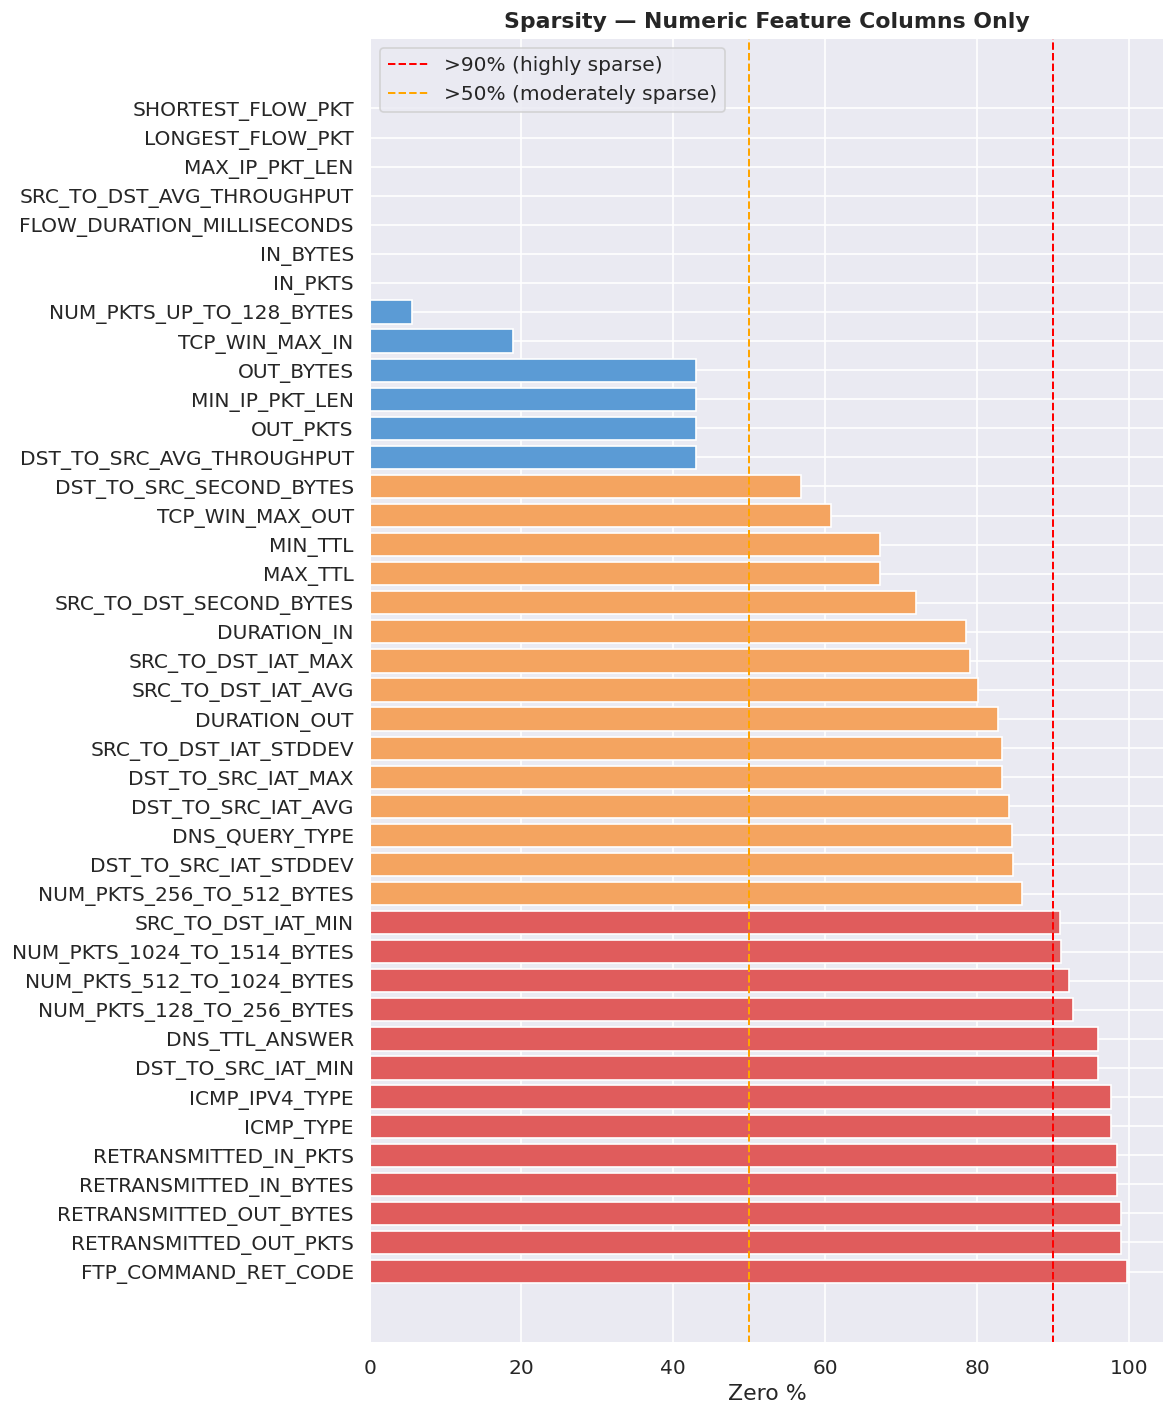

In [28]:
# columns where zero % is semantically meaningful
SPARSITY_COLS = [
    # flow volume
    "IN_BYTES", "OUT_BYTES", "IN_PKTS", "OUT_PKTS",
    # retransmissions
    "RETRANSMITTED_IN_BYTES", "RETRANSMITTED_IN_PKTS",
    "RETRANSMITTED_OUT_BYTES", "RETRANSMITTED_OUT_PKTS",
    # timing
    "FLOW_DURATION_MILLISECONDS", "DURATION_IN", "DURATION_OUT",
    # throughput
    "SRC_TO_DST_AVG_THROUGHPUT", "DST_TO_SRC_AVG_THROUGHPUT",
    "SRC_TO_DST_SECOND_BYTES",   "DST_TO_SRC_SECOND_BYTES",
    # packet sizes
    "LONGEST_FLOW_PKT", "SHORTEST_FLOW_PKT",
    "MIN_IP_PKT_LEN",   "MAX_IP_PKT_LEN",
    # packet size buckets
    "NUM_PKTS_UP_TO_128_BYTES",    "NUM_PKTS_128_TO_256_BYTES",
    "NUM_PKTS_256_TO_512_BYTES",   "NUM_PKTS_512_TO_1024_BYTES",
    "NUM_PKTS_1024_TO_1514_BYTES",
    # TTL & window
    "MIN_TTL", "MAX_TTL", "TCP_WIN_MAX_IN", "TCP_WIN_MAX_OUT",
    # IAT
    "SRC_TO_DST_IAT_MIN", "SRC_TO_DST_IAT_MAX",
    "SRC_TO_DST_IAT_AVG", "SRC_TO_DST_IAT_STDDEV",
    "DST_TO_SRC_IAT_MIN", "DST_TO_SRC_IAT_MAX",
    "DST_TO_SRC_IAT_AVG", "DST_TO_SRC_IAT_STDDEV",
    # protocol-specific sparse
    "ICMP_TYPE", "ICMP_IPV4_TYPE",
    "DNS_QUERY_TYPE", "DNS_TTL_ANSWER",
    "FTP_COMMAND_RET_CODE",
]

sparse_df = audit_df[audit_df["Column"].isin(SPARSITY_COLS)].copy()
sparse_df["Zero %"] = pd.to_numeric(sparse_df["Zero %"], errors="coerce")
sparse_df = sparse_df.sort_values("Zero %", ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ["#e05c5c" if z > 90 else "#f4a460" if z > 50 else "#5b9bd5"
          for z in sparse_df["Zero %"]]
ax.barh(sparse_df["Column"], sparse_df["Zero %"], color=colors)
ax.axvline(90, color="red",    lw=1.2, ls="--", label=">90% (highly sparse)")
ax.axvline(50, color="orange", lw=1.2, ls="--", label=">50% (moderately sparse)")
ax.set_xlabel("Zero %")
ax.set_title("Sparsity — Numeric Feature Columns Only", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
#  Protocol-specific sparse columns deep dive 
# ICMP, DNS, FTP are sparse because they're only non-zero for their protocol
# Let's verify: check their non-zero rows and see which attack classes they hit

sparse_proto_cols = {
    "ICMP"  : ["ICMP_TYPE", "ICMP_IPV4_TYPE"],
    "DNS"   : ["DNS_QUERY_TYPE", "DNS_TTL_ANSWER"],
    "FTP"   : ["FTP_COMMAND_RET_CODE"],
}

for proto, cols in sparse_proto_cols.items():
    filter_expr = pl.col(cols[0]) != 0
    count = lf.filter(filter_expr).select(pl.len()).collect().item()
    pct   = count / n_rows * 100

    # attack distribution within non-zero rows
    dist = (lf.filter(filter_expr)
              .select(TARGET)
              .collect()[TARGET]
              .value_counts(sort=True)
              .to_pandas())
    dist["pct"] = (dist["count"] / count * 100).round(2)

    print(f"\n{'='*55}")
    print(f"  {proto} flows  →  {count:,} rows  ({pct:.2f}% of dataset)")
    print(f"{'='*55}")
    print(dist.to_string(index=False))


  ICMP flows  →  645,415 rows  (2.35% of dataset)
    Attack  count   pct
    Benign 354348 54.90
  Backdoor 190616 29.53
      ddos  57731  8.94
  password  19367  3.00
       xss  16015  2.48
 injection   6126  0.95
  scanning    495  0.08
ransomware    468  0.07
      mitm    145  0.02
       dos    104  0.02

  DNS flows  →  4,245,088 rows  (15.43% of dataset)
   Attack   count   pct
   Benign 2786243 65.63
      xss 1244884 29.33
     ddos   95049  2.24
      dos   94471  2.23
injection   16469  0.39
     mitm    4677  0.11
 scanning    2107  0.05
 password    1120  0.03
 Backdoor      68  0.00

  FTP flows  →  88,226 rows  (0.32% of dataset)
  Attack  count   pct
password  56562 64.11
  Benign  31497 35.70
scanning    167  0.19


In [30]:
# All protocol subsets — flow count + attack distribution 

# L4 protocol code mapping
PROTO_NAMES = {6: "TCP", 17: "UDP", 1: "ICMP", 0: "HOPOPT", 58: "ICMPv6"}

# L7 nDPI code mapping
L7_NAMES = {
    0: "Unknown",  5: "DNS",    7: "HTTP",  10: "SMTP",
    18: "SSH",    21: "FTP",   62: "NetBIOS", 65: "DHCP",
    81: "NTP",    91: "HTTPS", 161: "SNMP",
}

print("=" * 60)
print("  L4 PROTOCOL BREAKDOWN")
print("=" * 60)

l4_protocols = (lf.select("PROTOCOL")
                  .collect()["PROTOCOL"]
                  .unique()
                  .to_list())

for proto_code in sorted(l4_protocols):
    proto_name = PROTO_NAMES.get(proto_code, f"code_{proto_code}")
    count = lf.filter(pl.col("PROTOCOL") == proto_code).select(pl.len()).collect().item()
    pct   = count / n_rows * 100

    dist = (lf.filter(pl.col("PROTOCOL") == proto_code)
              .select(TARGET)
              .collect()[TARGET]
              .value_counts(sort=True)
              .to_pandas())
    dist["pct"] = (dist["count"] / count * 100).round(2)

    print(f"\n  {proto_name} (code={proto_code})  →  {count:,} rows  ({pct:.2f}%)")
    print("  " + "-" * 50)
    for _, row in dist.iterrows():
        bar = "█" * int(row["pct"] / 2)
        print(f"    {row[TARGET]:<25} {int(row['count']):>10,}  {row['pct']:>6.2f}%  {bar}")


print("\n\n" + "=" * 60)
print("  L7 APPLICATION PROTOCOL BREAKDOWN (top 15)")
print("=" * 60)

l7_top = (lf.select("L7_PROTO")
            .collect()["L7_PROTO"]
            .value_counts(sort=True)
            .head(15)["L7_PROTO"]
            .to_list())

for proto_code in l7_top:
    proto_name = L7_NAMES.get(proto_code, f"code_{proto_code}")
    count = lf.filter(pl.col("L7_PROTO") == proto_code).select(pl.len()).collect().item()
    pct   = count / n_rows * 100

    dist = (lf.filter(pl.col("L7_PROTO") == proto_code)
              .select(TARGET)
              .collect()[TARGET]
              .value_counts(sort=True)
              .to_pandas())
    dist["pct"] = (dist["count"] / count * 100).round(2)

    print(f"\n  {proto_name} (code={proto_code})  →  {count:,} rows  ({pct:.2f}%)")
    print("  " + "-" * 50)
    for _, row in dist.iterrows():
        bar = "█" * int(row["pct"] / 2)
        print(f"    {row[TARGET]:<25} {int(row['count']):>10,}  {row['pct']:>6.2f}%  {bar}")


print("\n\n" + "=" * 60)
print("  PROTOCOL-SPECIFIC SPARSE COLUMNS")
print("=" * 60)

sparse_proto_cols = {
    "ICMP"  : ["ICMP_TYPE", "ICMP_IPV4_TYPE"],
    "DNS"   : ["DNS_QUERY_TYPE", "DNS_TTL_ANSWER"],
    "FTP"   : ["FTP_COMMAND_RET_CODE"],
}

for proto, cols in sparse_proto_cols.items():
    filter_expr = pl.col(cols[0]) != 0
    count = lf.filter(filter_expr).select(pl.len()).collect().item()
    pct   = count / n_rows * 100

    dist = (lf.filter(filter_expr)
              .select(TARGET)
              .collect()[TARGET]
              .value_counts(sort=True)
              .to_pandas())
    dist["pct"] = (dist["count"] / count * 100).round(2)

    print(f"\n  {proto} (non-zero rows)  →  {count:,} rows  ({pct:.2f}%)")
    print("  " + "-" * 50)
    for _, row in dist.iterrows():
        bar = "█" * int(row["pct"] / 2)
        print(f"    {row[TARGET]:<25} {int(row['count']):>10,}  {row['pct']:>6.2f}%  {bar}")

  L4 PROTOCOL BREAKDOWN

  ICMP (code=1)  →  215,377 rows  (0.78%)
  --------------------------------------------------
    Benign                       215,377  100.00%  ██████████████████████████████████████████████████

  code_2 (code=2)  →  24,847 rows  (0.09%)
  --------------------------------------------------
    Benign                        24,847  100.00%  ██████████████████████████████████████████████████

  TCP (code=6)  →  22,875,991 rows  (83.12%)
  --------------------------------------------------
    Benign                    13,608,306   59.49%  █████████████████████████████
    ddos                       4,046,204   17.69%  ████████
    password                   1,593,657    6.97%  ███
    xss                        1,589,533    6.95%  ███
    scanning                   1,355,672    5.93%  ██
    injection                    365,300    1.60%  
    Backdoor                     203,114    0.89%  
    dos                          108,985    0.48%  
    ransomware     

In [31]:
# TCP flags breakdown 
# 26 unique bitmask values 

flag_vc = (lf.select("TCP_FLAGS")
             .collect()["TCP_FLAGS"]
             .value_counts(sort=True)
             .to_pandas())
flag_vc["pct"]      = (flag_vc["count"] / n_rows * 100).round(3)

# decode common combinations
FLAG_NAMES = {
    0:  "No flags",
    1:  "FIN",
    2:  "SYN",
    4:  "RST",
    8:  "PSH",
    16: "ACK",
    17: "FIN+ACK",
    18: "SYN+ACK",
    20: "RST+ACK",
    24: "PSH+ACK",
    25: "FIN+PSH+ACK",
}
flag_vc["meaning"] = flag_vc["TCP_FLAGS"].map(FLAG_NAMES).fillna("other combination")
print(flag_vc.to_string(index=False))

 TCP_FLAGS   count    pct           meaning
         2 6447561 23.428               SYN
         0 4644270 16.876          No flags
        18 4176480 15.176           SYN+ACK
        27 3399624 12.353 other combination
        22 2620465  9.522 other combination
        17 2219485  8.065           FIN+ACK
        24 1720626  6.252           PSH+ACK
        16  525201  1.908               ACK
        20  487861  1.773           RST+ACK
        25  417053  1.515       FIN+PSH+ACK
        26  400596  1.456 other combination
        19  227988  0.828 other combination
        31  129243  0.470 other combination
        30   62024  0.225 other combination
        28   11773  0.043 other combination
        29    8565  0.031 other combination
         4    7644  0.028               RST
        41    7275  0.026 other combination
        21    5123  0.019 other combination
         6    1333  0.005 other combination
        23      55  0.000 other combination
       214       5  0.000 other 

In [32]:
# Protocol distribution 
proto_vc = (lf.select("PROTOCOL")
              .collect()["PROTOCOL"]
              .value_counts(sort=True)
              .to_pandas())
proto_vc["pct"] = (proto_vc["count"] / n_rows * 100).round(2)

PROTO_NAMES = {6: "TCP", 17: "UDP", 1: "ICMP", 0: "HOPOPT", 58: "ICMPv6"}
proto_vc["name"] = proto_vc["PROTOCOL"].map(PROTO_NAMES).fillna("other")
print(proto_vc.to_string(index=False))

 PROTOCOL    count   pct   name
        6 22875991 83.12    TCP
       17  4402790 16.00    UDP
        1   215377  0.78   ICMP
        2    24847  0.09  other
       58     1255  0.00 ICMPv6


Attack × Protocol counts:


PROTOCOL,ICMP,ICMPv6,TCP,UDP,other
Attack,,,,,
Backdoor,0,0,203114,270,0
Benign,215377,1255,13608306,2942429,24847
ddos,0,0,4046204,95052,0
dos,0,0,108985,94471,0
injection,0,0,365300,16477,0
mitm,0,0,1331,4682,0
password,0,0,1593657,1120,0
ransomware,0,0,3889,82,0
scanning,0,0,1355672,3305,0


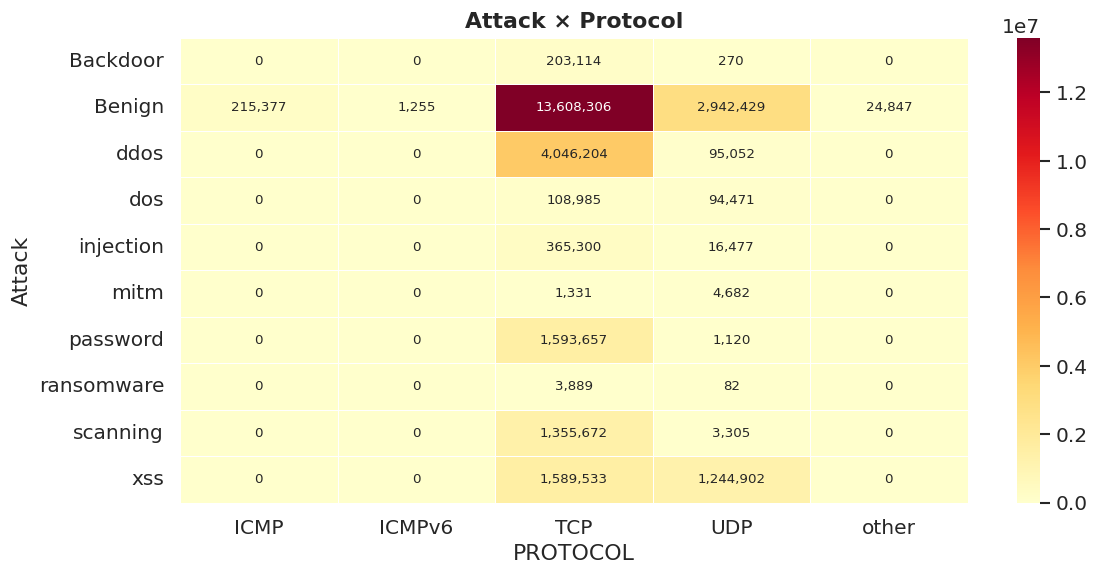

In [33]:
# Attack × Protocol cross-analysis 
cross = (lf.group_by([TARGET, "PROTOCOL"])
           .agg(pl.len().alias("count"))
           .collect()
           .to_pandas())

cross["PROTOCOL"] = cross["PROTOCOL"].map(PROTO_NAMES).fillna("other")
cross_pivot = (cross.pivot(index=TARGET, columns="PROTOCOL", values="count")
                    .fillna(0)
                    .astype(int))

print("Attack × Protocol counts:")
display(cross_pivot)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cross_pivot, cmap="YlOrRd", annot=True, fmt=",d",
            linewidths=0.4, annot_kws={"size": 8}, ax=ax)
ax.set_title("Attack × Protocol", fontweight="bold")
plt.tight_layout()
plt.show()

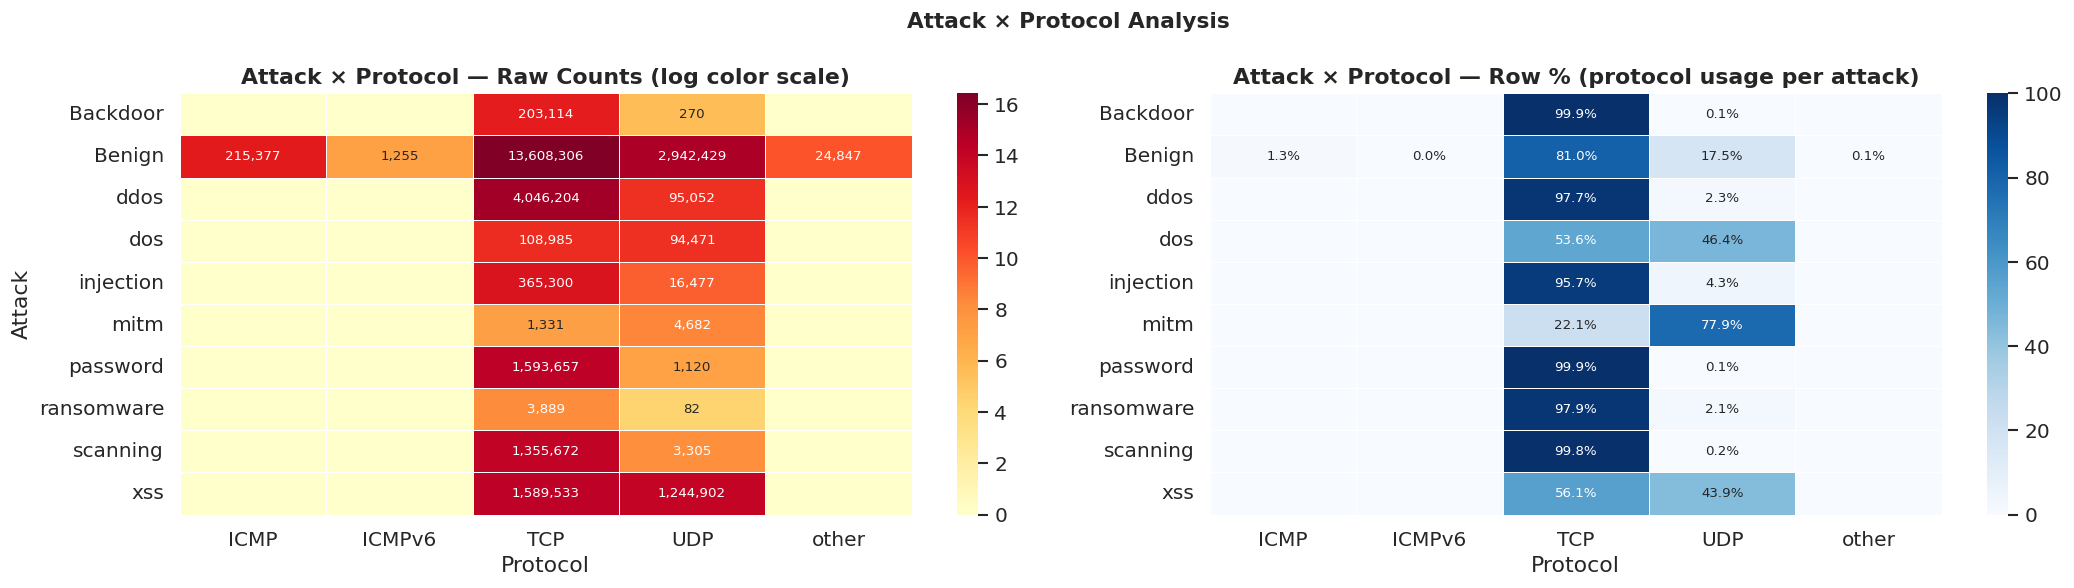


Protocol usage % per attack class:
PROTOCOL    ICMP  ICMPv6   TCP   UDP  other
Attack                                     
Backdoor     0.0     0.0  99.9   0.1    0.0
Benign       1.3     0.0  81.0  17.5    0.1
ddos         0.0     0.0  97.7   2.3    0.0
dos          0.0     0.0  53.6  46.4    0.0
injection    0.0     0.0  95.7   4.3    0.0
mitm         0.0     0.0  22.1  77.9    0.0
password     0.0     0.0  99.9   0.1    0.0
ransomware   0.0     0.0  97.9   2.1    0.0
scanning     0.0     0.0  99.8   0.2    0.0
xss          0.0     0.0  56.1  43.9    0.0


In [35]:
cross = (lf.group_by([TARGET, "PROTOCOL"])
           .agg(pl.len().alias("count"))
           .collect()
           .to_pandas())

cross["PROTOCOL"] = cross["PROTOCOL"].map(PROTO_NAMES).fillna("other")
cross_pivot = (cross.pivot(index=TARGET, columns="PROTOCOL", values="count")
                    .fillna(0)
                    .astype(int))

# normalize by row → each attack's protocol usage as %
cross_pct = cross_pivot.div(cross_pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── left: raw counts (log scale so minority classes are visible) ─────────────
cross_log = np.log1p(cross_pivot)
sns.heatmap(cross_log, cmap="YlOrRd",
            annot=cross_pivot.map(lambda x: f"{x:,}" if x > 0 else ""),
            fmt="", linewidths=0.4, annot_kws={"size": 8}, ax=axes[0])
axes[0].set_title("Attack × Protocol — Raw Counts (log color scale)",
                  fontweight="bold")
axes[0].set_xlabel("Protocol")
axes[0].set_ylabel("Attack")

# ── right: row-normalized % → protocol behavior per attack ───────────────────
sns.heatmap(cross_pct, cmap="Blues",
            annot=cross_pct.map(lambda x: f"{x:.1f}%" if x > 0 else ""),
            fmt="", linewidths=0.4, annot_kws={"size": 8},
            vmin=0, vmax=100, ax=axes[1])
axes[1].set_title("Attack × Protocol — Row % (protocol usage per attack)",
                  fontweight="bold")
axes[1].set_xlabel("Protocol")
axes[1].set_ylabel("")

plt.suptitle("Attack × Protocol Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── printed summary ───────────────────────────────────────────────────────────
print("\nProtocol usage % per attack class:")
print(cross_pct.round(1).to_string())

In [36]:
# L7 protocol top values
l7_vc = (lf.select("L7_PROTO")
           .collect()["L7_PROTO"]
           .value_counts(sort=True)
           .head(20)
           .to_pandas())
l7_vc["pct"] = (l7_vc["count"] / n_rows * 100).round(2)

# common nDPI L7 codes
L7_NAMES = {
    0: "Unknown", 7: "HTTP", 91: "HTTPS", 5: "DNS",
    21: "FTP", 161: "SNMP", 65: "DHCP", 81: "NTP",
    10: "SMTP", 18: "SSH", 62: "NetBIOS",
}
l7_vc["name"] = l7_vc["L7_PROTO"].map(L7_NAMES).fillna("other")
print(l7_vc.to_string(index=False))

 L7_PROTO   count   pct    name
        0 8452498 30.71 Unknown
        7 7304463 26.54    HTTP
       91 6155642 22.37   HTTPS
        5 4244397 15.42     DNS
        1  222886  0.81   other
       81  215377  0.78     NTP
      131  156372  0.57   other
       12   74799  0.27   other
        3   42728  0.16   other
       92   41337  0.15   other
       23   26853  0.10   other
       10   24860  0.09    SMTP
       82   24847  0.09   other
       89   23533  0.09   other
      170   23266  0.08   other
        4   21604  0.08   other
       51   19595  0.07   other
      158   18142  0.07   other
        8   16968  0.06   other
       88   16913  0.06   other


In [37]:
# ── Cell 10 : Retransmission columns — are they worth keeping? ────────────────
# 98-99% zeros — check if the non-zero values correlate with any attack type

retrans_cols = ["RETRANSMITTED_IN_BYTES", "RETRANSMITTED_IN_PKTS",
                "RETRANSMITTED_OUT_BYTES", "RETRANSMITTED_OUT_PKTS"]

for col in retrans_cols:
    nonzero = lf.filter(pl.col(col) > 0)
    count   = nonzero.select(pl.len()).collect().item()
    dist    = (nonzero.select(TARGET)
                      .collect()[TARGET]
                      .value_counts(sort=True)
                      .to_pandas())
    dist["pct"] = (dist["count"] / count * 100).round(2)
    print(f"\n{col}  →  {count:,} non-zero rows ({count/n_rows*100:.2f}%)")
    print(dist.to_string(index=False))


RETRANSMITTED_IN_BYTES  →  429,372 non-zero rows (1.56%)
    Attack  count   pct
  Backdoor 190616 44.39
    Benign 138250 32.20
      ddos  57735 13.45
  password  19367  4.51
       xss  16064  3.74
 injection   6126  1.43
  scanning    495  0.12
ransomware    468  0.11
      mitm    145  0.03
       dos    106  0.02

RETRANSMITTED_IN_PKTS  →  429,372 non-zero rows (1.56%)
    Attack  count   pct
  Backdoor 190616 44.39
    Benign 138250 32.20
      ddos  57735 13.45
  password  19367  4.51
       xss  16064  3.74
 injection   6126  1.43
  scanning    495  0.12
ransomware    468  0.11
      mitm    145  0.03
       dos    106  0.02

RETRANSMITTED_OUT_BYTES  →  283,184 non-zero rows (1.03%)
    Attack  count   pct
      ddos 259829 91.75
    Benign  13120  4.63
       xss   6976  2.46
 injection   2629  0.93
  password    330  0.12
  scanning    135  0.05
      mitm    116  0.04
       dos     39  0.01
ransomware      6  0.00
  Backdoor      4  0.00

RETRANSMITTED_OUT_PKTS  →  283,18

## Class Distribution

In [38]:
vc = (lf.select(TARGET)
        .collect()[TARGET]
        .value_counts(sort=True))

vc_pd = vc.to_pandas()
vc_pd["pct"] = vc_pd["count"] / n_rows * 100

In [39]:
# ── Multi-class  ─────────────────────────────────────────────────────────
print("MULTI-CLASS  (Attack type)")
print(f"  {'Attack':<28} {'Count':>10}   {'Share'}")
print("  " + "─" * 58)
for _, row in vc_pd.iterrows():
    bar = "█" * int(row["pct"] / 2)
    print(f"  {row[TARGET]:<28} {int(row['count']):>10,}   {bar}  {row['pct']:.2f}%")
print("  " + "─" * 58)
print(f"  {'TOTAL':<28} {n_rows:>10,}   100.00%")

MULTI-CLASS  (Attack type)
  Attack                            Count   Share
  ──────────────────────────────────────────────────────────
  Benign                       16,792,214   ██████████████████████████████  61.02%
  ddos                          4,141,256   ███████  15.05%
  xss                           2,834,435   █████  10.30%
  password                      1,594,777   ██  5.79%
  scanning                      1,358,977   ██  4.94%
  injection                       381,777     1.39%
  dos                             203,456     0.74%
  Backdoor                        203,384     0.74%
  mitm                              6,013     0.02%
  ransomware                        3,971     0.01%
  ──────────────────────────────────────────────────────────
  TOTAL                        27,520,260   100.00%


In [40]:
print("\nBINARY  (Benign vs Attack)")

binary_pd = vc_pd.copy()
binary_pd["binary"] = binary_pd[TARGET].apply(
    lambda x: "Benign" if x.lower() == "benign" else "Attack"
)
binary_pd = (binary_pd.groupby("binary", as_index=False)["count"]
                       .sum()
                       .sort_values("count", ascending=False))
binary_pd["pct"] = binary_pd["count"] / n_rows * 100

print(f"  {'Class':<28} {'Count':>10}   {'Share'}")
print("  " + "─" * 58)
for _, row in binary_pd.iterrows():
    bar = "█" * int(row["pct"] / 2)
    print(f"  {row['binary']:<28} {int(row['count']):>10,}   {bar}  {row['pct']:.2f}%")
print("  " + "─" * 58)
print(f"  {'TOTAL':<28} {n_rows:>10,}   100.00%")


BINARY  (Benign vs Attack)
  Class                             Count   Share
  ──────────────────────────────────────────────────────────
  Benign                       16,792,214   ██████████████████████████████  61.02%
  Attack                       10,728,046   ███████████████████  38.98%
  ──────────────────────────────────────────────────────────
  TOTAL                        27,520,260   100.00%


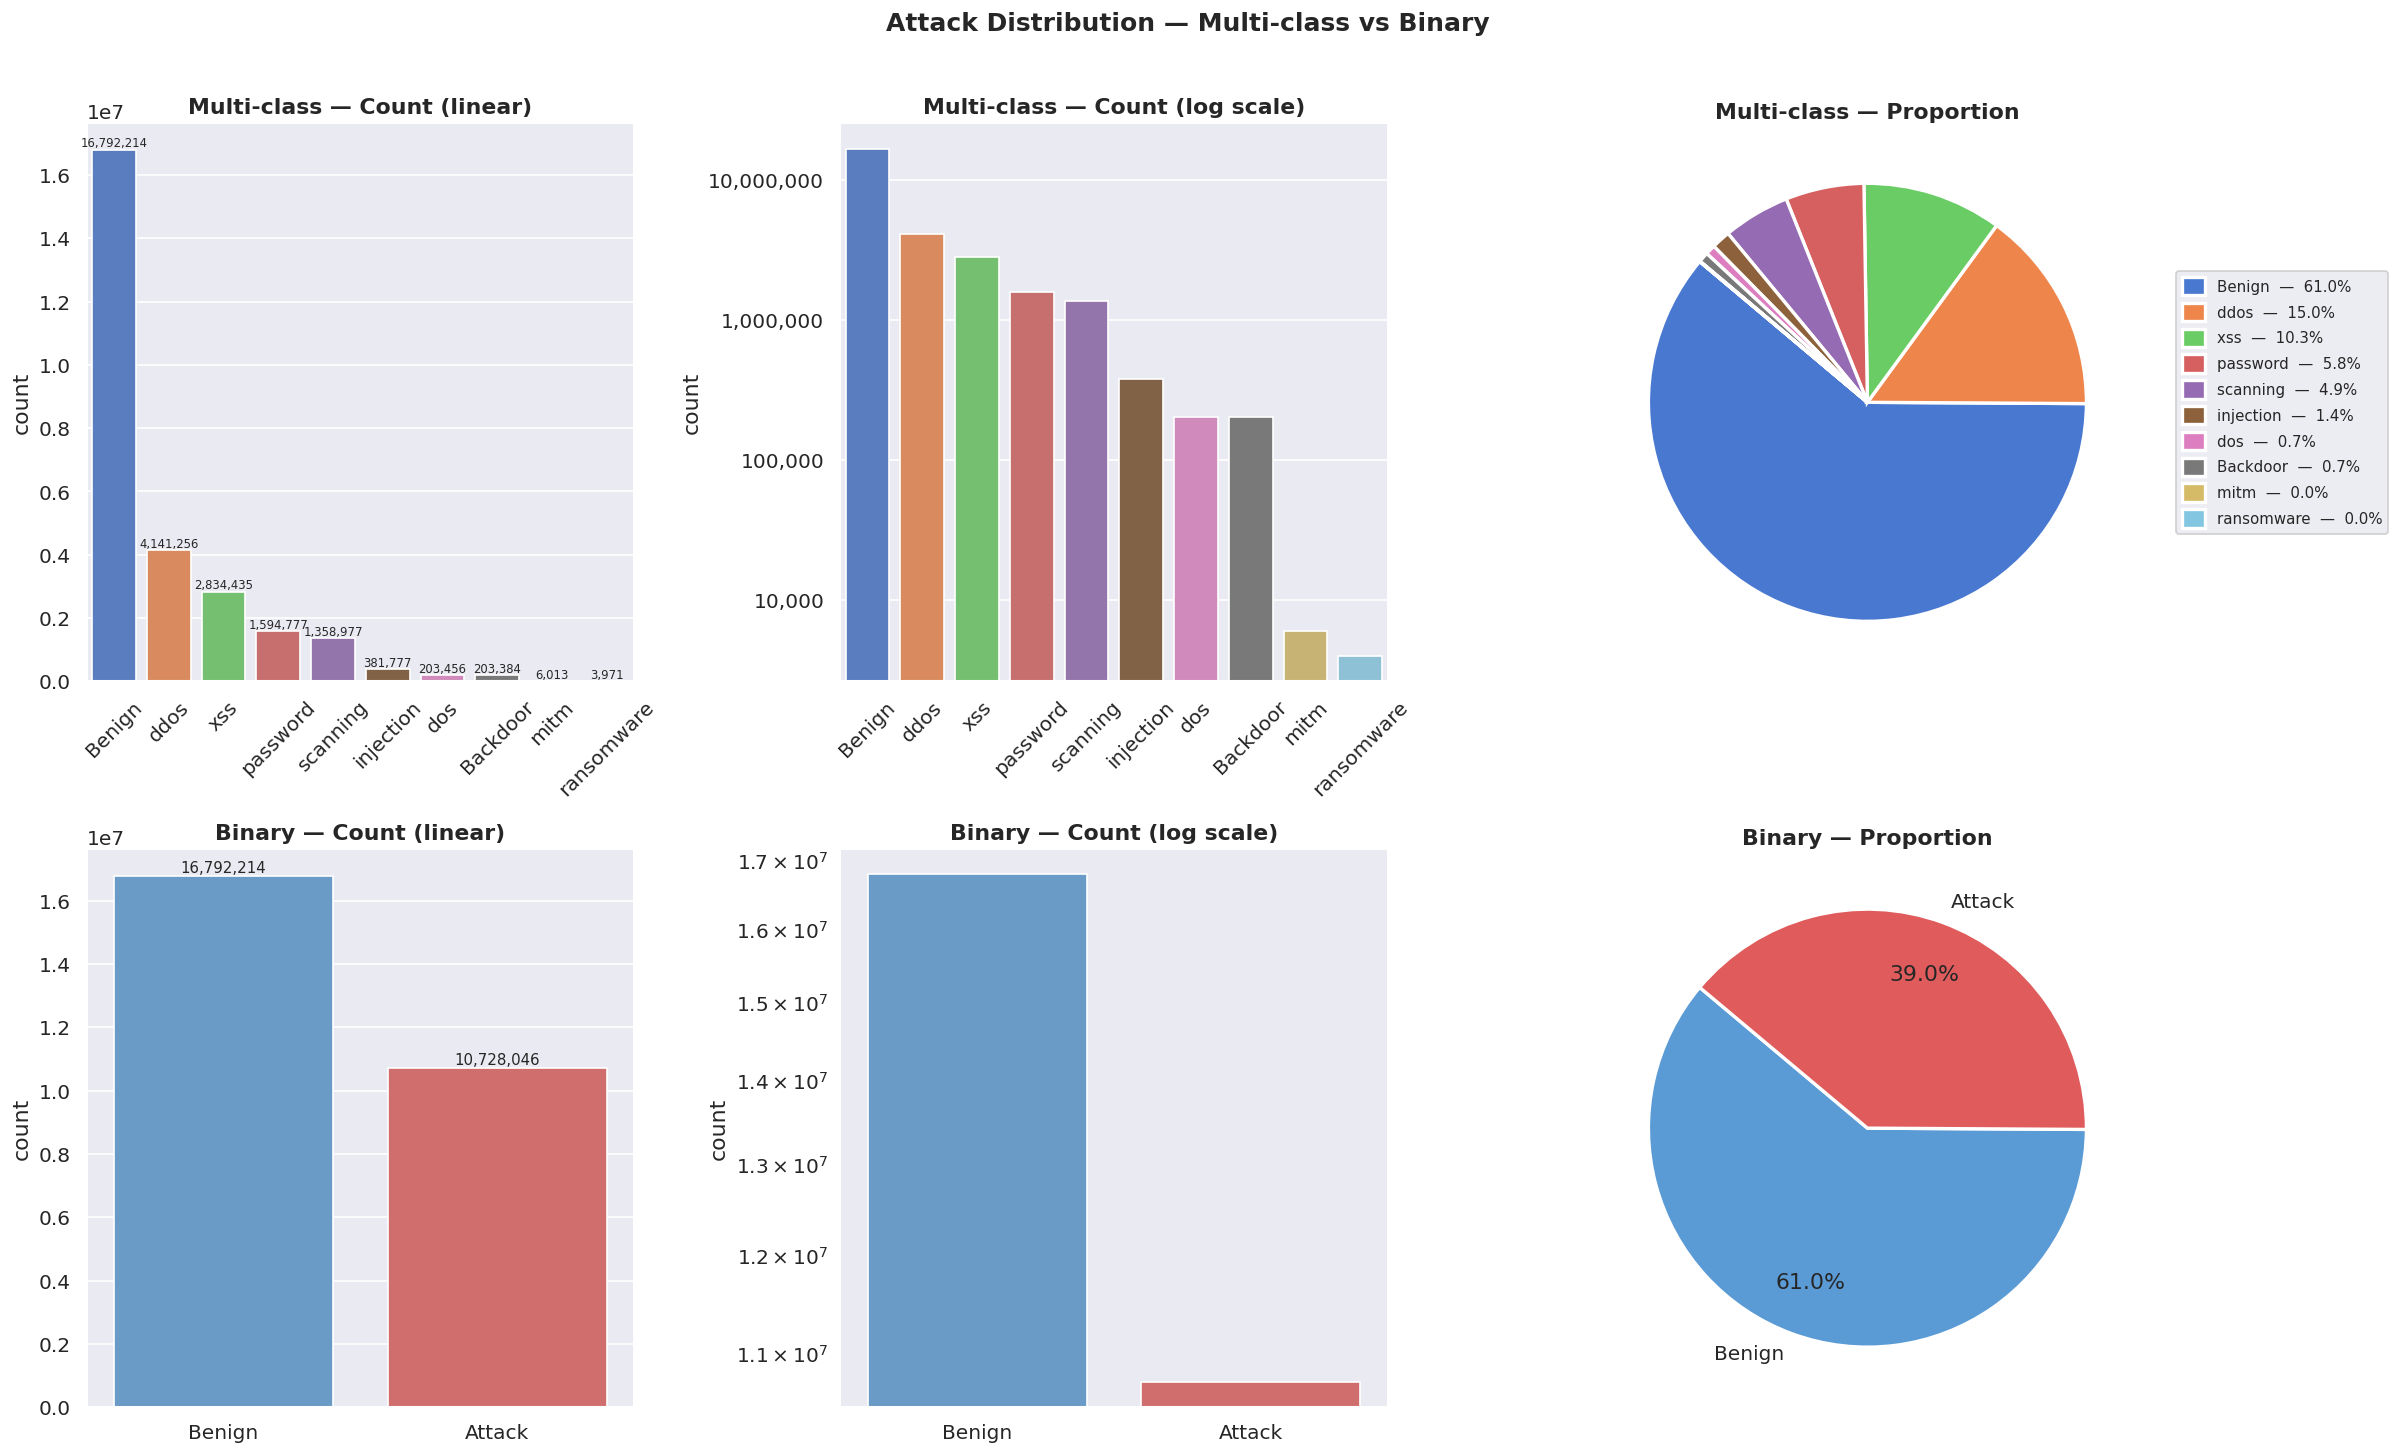

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
PALETTE     = "muted"
order  = vc_pd.sort_values("count", ascending=False)[TARGET]
colors = sns.color_palette(PALETTE, len(vc_pd))

# ── ROW 1 — Multi-class ───────────────────────────────────────────────────────

# count bar
sns.barplot(data=vc_pd, x=TARGET, y="count", order=order,
            palette=PALETTE, ax=axes[0][0])
axes[0][0].set_title("Multi-class — Count (linear)", fontweight="bold")
axes[0][0].set_xlabel(""); axes[0][0].tick_params(axis="x", rotation=45)
for bar in axes[0][0].patches:
    h = bar.get_height()
    axes[0][0].text(bar.get_x() + bar.get_width()/2, h,
                    f"{int(h):,}", ha="center", va="bottom", fontsize=7)

# log bar
sns.barplot(data=vc_pd, x=TARGET, y="count", order=order,
            palette=PALETTE, ax=axes[0][1])
axes[0][1].set_yscale("log")
axes[0][1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
axes[0][1].set_title("Multi-class — Count (log scale)", fontweight="bold")
axes[0][1].set_xlabel(""); axes[0][1].tick_params(axis="x", rotation=45)

# pie
wedges, texts = axes[0][2].pie(
    vc_pd["count"],
    colors=colors,
    startangle=140,
    wedgeprops={"linewidth": 2, "edgecolor": "white"},
)

# legend with color + name + percentage
legend_labels = [
    f"{getattr(row, TARGET)}  —  {getattr(row, 'count') / n_rows * 100:.1f}%"
    for row in vc_pd.itertuples()
]

axes[0][2].legend(
    wedges,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=9,
    frameon=True,
    framealpha=0.9,
    edgecolor="#cccccc",
    handlelength=1.5,
    handleheight=1.5,
)

axes[0][2].set_title("Multi-class — Proportion", fontweight="bold")

# ── ROW 2 — Binary ────────────────────────────────────────────────────────────
bin_colors = ["#5b9bd5", "#e05c5c"]

# count bar
sns.barplot(data=binary_pd, x="binary", y="count",
            palette=bin_colors, ax=axes[1][0])
axes[1][0].set_title("Binary — Count (linear)", fontweight="bold")
axes[1][0].set_xlabel("")
for bar in axes[1][0].patches:
    h = bar.get_height()
    axes[1][0].text(bar.get_x() + bar.get_width()/2, h,
                    f"{int(h):,}", ha="center", va="bottom", fontsize=9)

# log bar
sns.barplot(data=binary_pd, x="binary", y="count",
            palette=bin_colors, ax=axes[1][1])
axes[1][1].set_yscale("log")
axes[1][1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
axes[1][1].set_title("Binary — Count (log scale)", fontweight="bold")
axes[1][1].set_xlabel("")

# pie
axes[1][2].pie(binary_pd["count"], labels=binary_pd["binary"],
               autopct="%1.1f%%", colors=bin_colors,
               startangle=140, pctdistance=0.75,
               wedgeprops={"linewidth": 2, "edgecolor": "white"})
axes[1][2].set_title("Binary — Proportion", fontweight="bold")

plt.suptitle("Attack Distribution — Multi-class vs Binary",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Flow Length Distribution

In [42]:
# ── Flow Length Distribution by Attack Class ──────────────────────────────────

flow_col = "FLOW_DURATION_MILLISECONDS"

# ── Cell 1 : Summary statistics per attack ────────────────────────────────────
stats = (lf.group_by(TARGET)
           .agg([
               pl.col(flow_col).min().alias("min"),
               pl.col(flow_col).quantile(0.25).alias("q25"),
               pl.col(flow_col).median().alias("median"),
               pl.col(flow_col).mean().alias("mean"),
               pl.col(flow_col).quantile(0.75).alias("q75"),
               pl.col(flow_col).max().alias("max"),
               pl.col(flow_col).std().alias("std"),
               (pl.col(flow_col) == 0).sum().alias("zero_count"),
               pl.len().alias("total"),
           ])
           .collect()
           .to_pandas()
           .sort_values("median", ascending=False))

stats["zero_%"] = (stats["zero_count"] / stats["total"] * 100).round(2)

for col in ["min", "q25", "median", "mean", "q75", "max", "std"]:
    stats[col] = stats[col].round(1)

display(stats[[TARGET, "min", "q25", "median", "mean", "q75",
               "max", "std", "zero_%", "total"]].reset_index(drop=True))

,Attack,min,q25,median,mean,q75,max,std,zero_%,total
0,Backdoor,1,1031.0,1500.0,1266.5,1531.0,1999,452.9,0.0,203384
1,injection,1,107.0,289.0,450.4,593.0,1988,475.7,0.0,381777
2,dos,1,2.0,150.0,117.6,201.0,1992,132.6,0.0,203456
3,ransomware,1,7.0,34.0,191.9,64.0,1987,432.8,0.0,3971
4,mitm,1,14.0,33.0,3539.4,95.0,120341,17661.0,0.0,6013
5,xss,1,3.0,26.0,293.5,433.0,1996,437.5,0.0,2834435
6,password,1,3.0,20.0,683.4,474.0,120680,4358.1,0.0,1594777
7,ddos,1,1.0,1.0,98.1,1.0,1999,331.6,0.0,4141256
8,Benign,1,1.0,1.0,97.7,1.0,120999,1654.8,0.0,16792214
9,scanning,1,1.0,1.0,9.5,1.0,1999,90.7,0.0,1358977


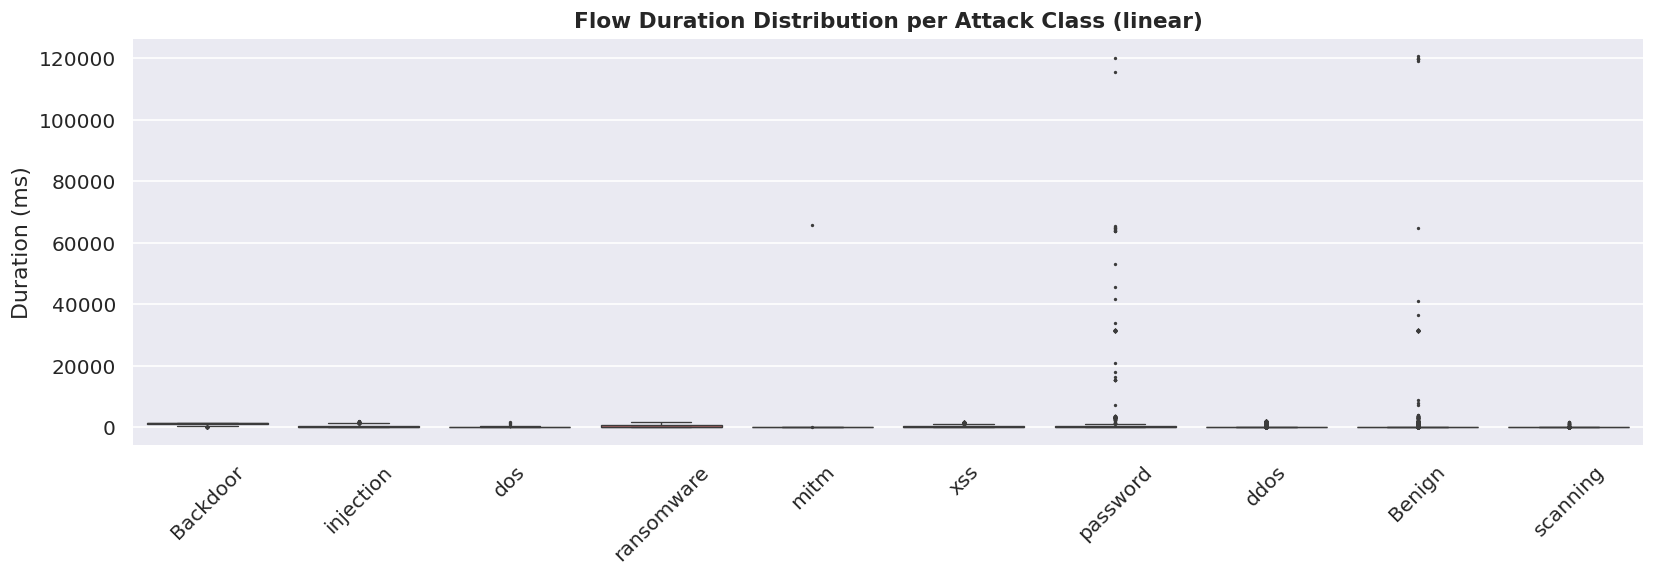

In [43]:
# ── Cell 2 : Box plot — linear scale ─────────────────────────────────────────
plot_df = (lf.select([TARGET, flow_col])
             .collect()
             .sample(min(80_000, n_rows), seed=42)
             .to_pandas())

order = (stats.sort_values("median", ascending=False)[TARGET].tolist())

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=plot_df, x=TARGET, y=flow_col,
            order=order, palette=PALETTE,
            fliersize=1, linewidth=0.8, ax=ax)
ax.set_title("Flow Duration Distribution per Attack Class (linear)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Duration (ms)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

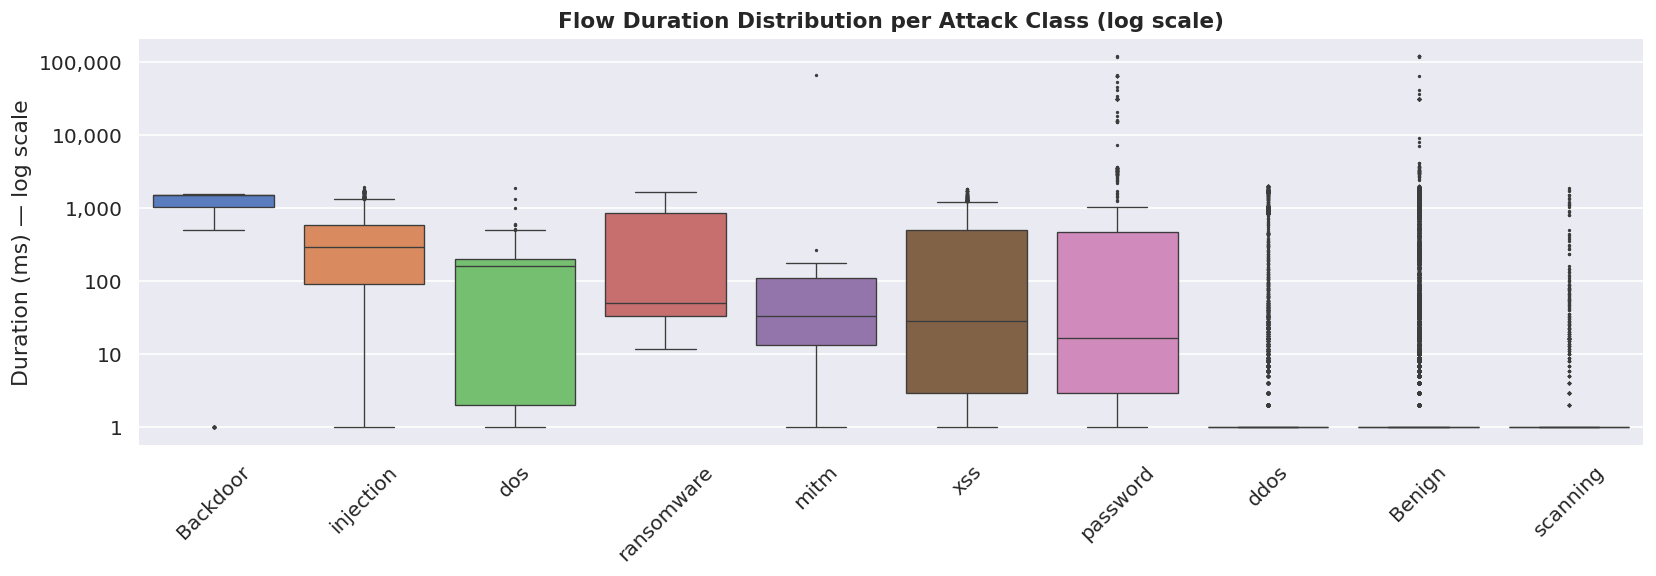

In [44]:
# ── Cell 3 : Box plot — log scale (reveals low-duration attacks) ──────────────
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=plot_df, x=TARGET, y=flow_col,
            order=order, palette=PALETTE,
            fliersize=1, linewidth=0.8, ax=ax)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Flow Duration Distribution per Attack Class (log scale)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Duration (ms) — log scale")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

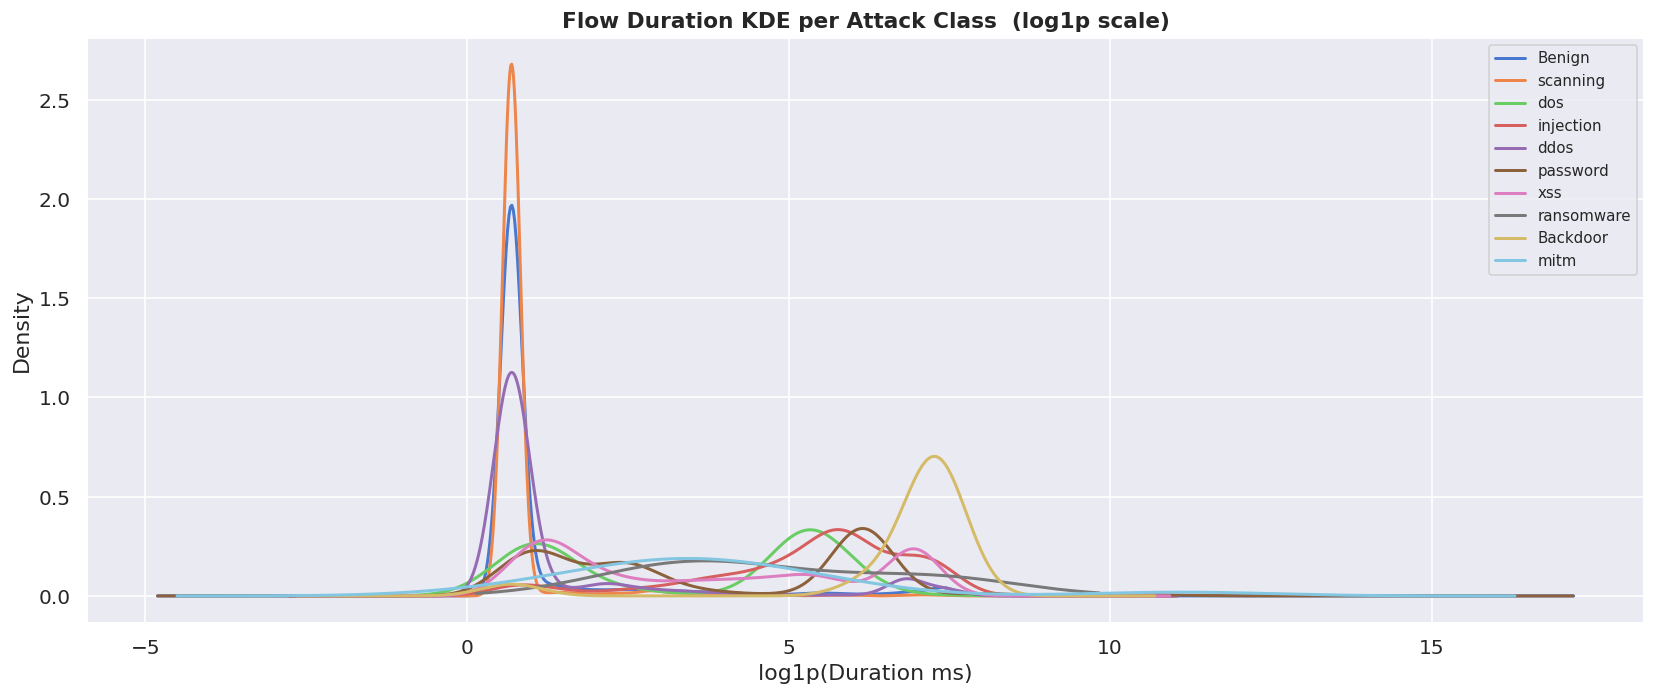

In [47]:
# ── Cell 4 : KDE per attack — log-transformed x axis ─────────────────────────
# add small constant to handle zeros before log
plot_df["log_duration"] = np.log1p(plot_df[flow_col])

attacks  = plot_df[TARGET].unique()
colors   = sns.color_palette(PALETTE, len(attacks))

fig, ax = plt.subplots(figsize=(14, 6))
for atk, col in zip(attacks, colors):
    data = plot_df[plot_df[TARGET] == atk]["log_duration"].dropna()
    data.plot.kde(ax=ax, label=atk, color=col, linewidth=1.8)

ax.set_title("Flow Duration KDE per Attack Class  (log1p scale)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("log1p(Duration ms)")
ax.set_ylabel("Density")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

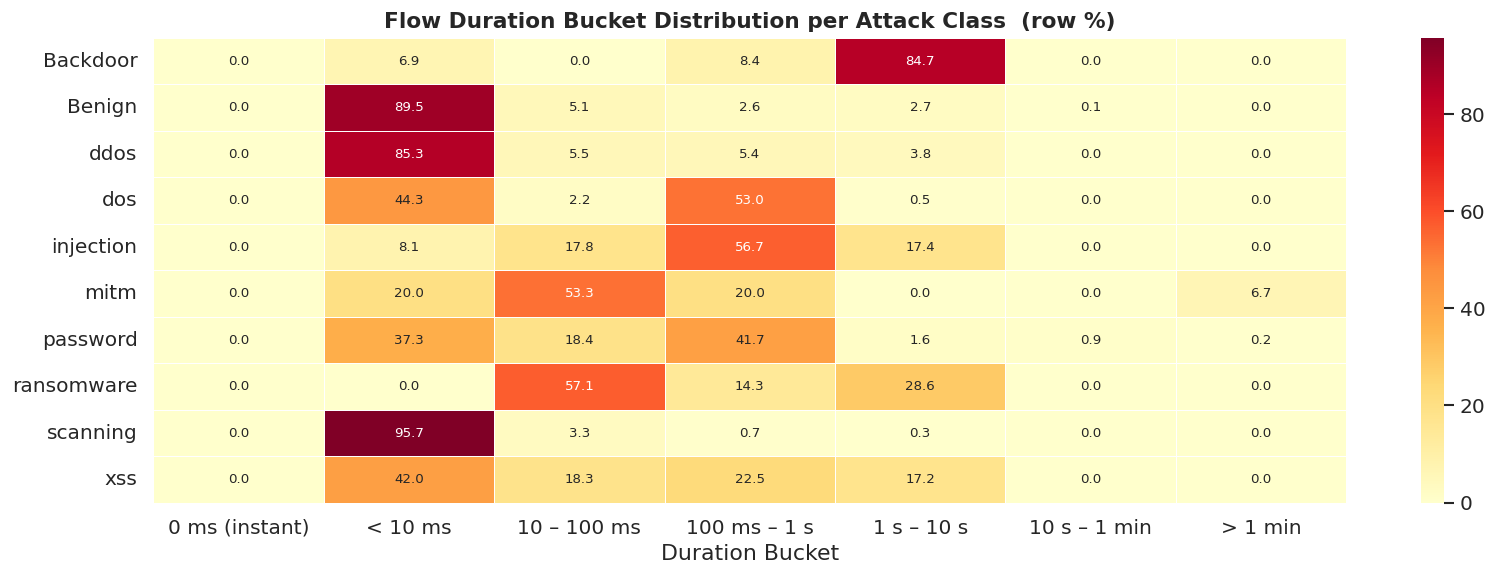


Row % (each attack's duration profile):


bucket,0 ms (instant),< 10 ms,10 – 100 ms,100 ms – 1 s,1 s – 10 s,10 s – 1 min,> 1 min
Attack,,,,,,,
Backdoor,0.0,6.9,0.0,8.4,84.7,0.0,0.0
Benign,0.0,89.5,5.1,2.6,2.7,0.1,0.0
ddos,0.0,85.3,5.5,5.4,3.8,0.0,0.0
dos,0.0,44.3,2.2,53.0,0.5,0.0,0.0
injection,0.0,8.1,17.8,56.7,17.4,0.0,0.0
mitm,0.0,20.0,53.3,20.0,0.0,0.0,6.7
password,0.0,37.3,18.4,41.7,1.6,0.9,0.2
ransomware,0.0,0.0,57.1,14.3,28.6,0.0,0.0
scanning,0.0,95.7,3.3,0.7,0.3,0.0,0.0


In [48]:
# ── Cell 5 : Duration buckets — how flows distribute across time ranges ────────
# bucket the durations into human-readable ranges
def duration_bucket(ms):
    if ms == 0:        return "0 ms (instant)"
    elif ms < 10:      return "< 10 ms"
    elif ms < 100:     return "10 – 100 ms"
    elif ms < 1_000:   return "100 ms – 1 s"
    elif ms < 10_000:  return "1 s – 10 s"
    elif ms < 60_000:  return "10 s – 1 min"
    else:              return "> 1 min"

BUCKET_ORDER = [
    "0 ms (instant)", "< 10 ms", "10 – 100 ms",
    "100 ms – 1 s", "1 s – 10 s", "10 s – 1 min", "> 1 min"
]

plot_df["bucket"] = plot_df[flow_col].apply(duration_bucket)

bucket_cross = (plot_df.groupby([TARGET, "bucket"])
                       .size()
                       .reset_index(name="count"))

# normalise per attack class → % of that class in each bucket
totals = bucket_cross.groupby(TARGET)["count"].transform("sum")
bucket_cross["pct"] = bucket_cross["count"] / totals * 100

pivot = (bucket_cross.pivot(index=TARGET, columns="bucket", values="pct")
                     .reindex(columns=BUCKET_ORDER)
                     .fillna(0))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".1f",
            linewidths=0.4, annot_kws={"size": 8}, ax=ax)
ax.set_title("Flow Duration Bucket Distribution per Attack Class  (row %)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Duration Bucket")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("\nRow % (each attack's duration profile):")
display(pivot.round(1))

In [50]:
# compute each stat lazily — never loads full data into RAM
agg_exprs = []
for c in NUM_COLS:
    agg_exprs += [
        pl.col(c).mean().alias(f"{c}__mean"),
        pl.col(c).std().alias(f"{c}__std"),
        pl.col(c).min().alias(f"{c}__min"),
        pl.col(c).max().alias(f"{c}__max"),
        pl.col(c).quantile(0.25).alias(f"{c}__q25"),
        pl.col(c).quantile(0.50).alias(f"{c}__median"),
        pl.col(c).quantile(0.75).alias(f"{c}__q75"),
    ]

result = lf.select(agg_exprs).collect().to_pandas()

# reshape into a readable table: rows = features, cols = stats
rows = []
for c in NUM_COLS:
    rows.append({
        "Feature" : c,
        "Mean"    : round(result[f"{c}__mean"][0], 4),
        "Std"     : round(result[f"{c}__std"][0], 4),
        "Min"     : round(result[f"{c}__min"][0], 4),
        "Q25"     : round(result[f"{c}__q25"][0], 4),
        "Median"  : round(result[f"{c}__median"][0], 4),
        "Q75"     : round(result[f"{c}__q75"][0], 4),
        "Max"     : round(result[f"{c}__max"][0], 4),
    })

stats_df = pd.DataFrame(rows).set_index("Feature")
display(stats_df)

,Mean,Std,Min,Q25,Median,Q75,Max
Feature,,,,,,,
FLOW_START_MILLISECONDS,1.556211e+12,1.462831e+08,1556028590618,1.556077e+12,1.556225e+12,1.556303e+12,1556549155177
FLOW_END_MILLISECONDS,1.556211e+12,1.462832e+08,1556028590618,1.556077e+12,1.556225e+12,1.556303e+12,1556549155861
L4_SRC_PORT,3.298734e+04,2.270672e+04,0,4.430000e+02,4.052500e+04,5.162100e+04,65535
L4_DST_PORT,1.816723e+04,2.277636e+04,0,8.000000e+01,2.046000e+03,4.217600e+04,65535
PROTOCOL,7.719400e+00,4.090800e+00,1,6.000000e+00,6.000000e+00,6.000000e+00,58
L7_PROTO,2.733170e+01,4.362540e+01,0,0.000000e+00,7.000000e+00,8.100000e+01,401
IN_BYTES,4.544818e+02,3.886208e+04,4,4.800000e+01,6.700000e+01,1.200000e+02,79846944
IN_PKTS,4.049300e+00,6.241651e+02,1,1.000000e+00,1.000000e+00,2.000000e+00,1220131
OUT_BYTES,3.722711e+02,2.762322e+04,0,0.000000e+00,4.000000e+01,6.500000e+01,70221306
